# CNT-forest Einzel lens: two-step build-and-test workflow

This notebook restructures the trajectory study into a **clean two-step process**:

1. **Create a specific lens + emitter** by directly specifying the full device geometry, voltages, emitter geometry, emission-model parameters, computational domain, and electrostatic grid.
2. **Test that specific lens** by computing electron trajectories from a launch bundle whose radial extent is derived from the **current CNT-forest dimensions**.

## Why this version is safer for manual studies
- the device is built from an **explicit full parameter set**, not from partial overrides that can accidentally leave old geometry values in memory,
- the trajectory launch radius is always tied to the **active** `R_forest` and `emission_edge_exclusion`,
- the notebook reports the actual **launch extent** and simple **resolution diagnostics** before and after the solve,
- rebuilding the lens and testing the lens are now **separate actions**, so you can change the physics without silently rerunning unrelated parts.

The electrostatics notebook is still assumed to be in the same directory and is used here as the source of the solver and geometry utilities.

In [1]:

from __future__ import annotations

import io
import math
import copy
import textwrap
import contextlib
from dataclasses import dataclass
from pathlib import Path

import nbformat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.interpolate import RectBivariateSpline

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.6e}".format



## 1. Load context from the electrostatics notebook

The previous notebook already contains the geometry builder, electrostatic solver, and case builder.  
Here we load only the cells needed for:
- baseline parameters,
- geometry construction,
- field solves for sweeps,
- the effective canopy-emission helper (useful for launch weighting if desired).


In [2]:
PREVIOUS_NOTEBOOK = "cnt_forest_einzel_research_grade.ipynb"
BASELINE_ARRAY_FILE = "cnt_forest_einzel_baseline_arrays.npz"

FORCE_REBUILD_BASELINE = False
REBUILD_GRID = None          # example: (181, 421) or None to use baseline grid from previous notebook

# trajectory controls
T_MAX = 5.0e-9
MAX_STEP = 5.0e-12
RTOL = 1.0e-9
ATOL = np.array([1e-12, 1e-12, 1e-30, 1e-30], dtype=float)

# launch controls
DEFAULT_LAUNCH_MODE = "emission_all_faces"   # "uniform_radius", "emission_quantiles", or "emission_all_faces"
DEFAULT_N_RAYS = 201                         # used directly by uniform/quantile modes
DEFAULT_N_SUBRAYS_PER_FACE = 2               # used by emission_all_faces
DEFAULT_INITIAL_ENERGY_EV = 0.2
DEFAULT_HALF_ANGLE_DEG = 0.0                 # used directly only for angle_mode="delta"
DEFAULT_ANGLE_MODE = "gaussian"              # "delta" or "gaussian"
DEFAULT_ANGLE_SIGMA_DEG = 2.0
DEFAULT_ANGLE_MAX_DEG = 8.0
DEFAULT_ENERGY_MODE = "gaussian"             # "delta" or "gaussian"
DEFAULT_ENERGY_SIGMA_EV = 0.10
DEFAULT_ENERGY_MIN_EV = 0.01
DEFAULT_Z_OFFSET = 5.0e-9
DEFAULT_RNG_SEED = 12345

# sweep controls
SWEEP_GRID = (121, 281)  # coarse exploratory sweep; refine promising regions afterward
V_MID_SWEEP = np.linspace(300.0, 1500.0, 5)

In [3]:

def resolve_existing_path(filename: str | Path) -> Path:
    """Resolve a file path robustly for notebook use.

    Search order:
    1. exact path as given,
    2. current working directory / filename,
    3. recursive search under the current working directory,
    4. /mnt/data / filename and recursive search under /mnt/data (useful in this ChatGPT environment).
    """
    candidate = Path(filename)
    if candidate.exists():
        return candidate.resolve()

    direct_candidates = [
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
    ]
    for cand in direct_candidates:
        if cand.exists():
            return cand.resolve()

    search_roots = [Path.cwd()]
    mnt_data = Path("/mnt/data")
    if mnt_data.exists():
        search_roots.append(mnt_data)

    for root in search_roots:
        matches = list(root.rglob(str(filename)))
        if matches:
            return matches[0].resolve()

    raise FileNotFoundError(f"Could not locate {filename!s}. Place it in the same directory or update the filename.")


def load_previous_notebook_context(previous_notebook: str | Path) -> dict:
    """Load selected code cells from the electrostatics notebook into a namespace."""
    previous_notebook = resolve_existing_path(previous_notebook)

    nb = nbformat.read(previous_notebook, as_version=4)

    selectors = [
        "import time",
        "# -----------------------------\n# Voltages",
        "z1_start = d1",
        "def trapz_compat",
        "def build_axisymmetric_eps_matrix",
        "def scatter_solution_to_grid",
        "A_FN = 1.541434e-6",
        "def build_case",
    ]

    namespace: dict = {}
    with contextlib.redirect_stdout(io.StringIO()):
        for marker in selectors:
            matched = None
            for cell in nb.cells:
                if cell.cell_type == "code" and marker in cell.source:
                    matched = cell.source
                    break
            if matched is None:
                raise RuntimeError(f"Could not find the required code block containing: {marker!r}")
            exec(matched, namespace)

    required = [
        "params",
        "baseline_grid",
        "R_outer",
        "z_extra",
        "build_case",
        "build_geometry",
        "compute_forest_emission",
    ]
    missing = [name for name in required if name not in namespace]
    if missing:
        raise RuntimeError(f"Previous notebook context is missing required objects: {missing}")
    return namespace


ctx = load_previous_notebook_context(PREVIOUS_NOTEBOOK)
params_base = copy.deepcopy(ctx["params"])
baseline_grid_from_prev = tuple(ctx["baseline_grid"])
R_outer_from_prev = float(ctx["R_outer"])
z_extra_from_prev = float(ctx["z_extra"])

print("Loaded context from:", resolve_existing_path(PREVIOUS_NOTEBOOK))
print("Baseline grid from previous notebook:", baseline_grid_from_prev)
print("Baseline V_MID [V]:", params_base["V_MID"])


Loaded context from: C:\Users\surya\OneDrive\Desktop\NANOTECH\E-Beam-Website-Repository\website_code\Einzel_Study\cnt_forest_einzel_research_grade.ipynb
Baseline grid from previous notebook: (181, 421)
Baseline V_MID [V]: 10000.0



## 2. Geometry and baseline-field helpers


In [4]:

def refresh_derived_geometry_params(params: dict) -> dict:
    """Recompute dependent axial positions after any geometry change."""
    p = copy.deepcopy(params)
    p["z1_start"] = p["d1"]
    p["z1_end"] = p["z1_start"] + p["t_e"]
    p["z2_start"] = p["z1_end"] + p["d2"]
    p["z2_end"] = p["z2_start"] + p["t_e"]
    p["z3_start"] = p["z2_end"] + p["d3"]
    p["z3_end"] = p["z3_start"] + p["t_e"]
    return p


def load_or_build_baseline(
    params: dict,
    array_file: str | Path = BASELINE_ARRAY_FILE,
    force_rebuild: bool = FORCE_REBUILD_BASELINE,
    rebuild_grid=None,
):
    """Load saved baseline arrays if available; otherwise rebuild the baseline case."""
    params = refresh_derived_geometry_params(params)

    try:
        array_path = resolve_existing_path(array_file)
    except FileNotFoundError:
        array_path = Path(array_file)

    if array_path.exists() and not force_rebuild:
        arr = np.load(array_path)
        r = arr["r"]
        z = arr["z"]
        V = arr["V_direct"]
        Er = arr["Er_direct"]
        Ez = arr["Ez_direct"]
        E = arr["E_direct"]

        geom = ctx["build_geometry"](r, z, params)
        case = {
            "r": r,
            "z": z,
            "dr": float(r[1] - r[0]),
            "dz": float(z[1] - z[0]),
            "geom": geom,
            "V_direct": V,
            "Er_direct": Er,
            "Ez_direct": Ez,
            "E_direct": E,
            "R_outer": float(r[-1]),
            "z_extra": float(z[-1] - params["z3_end"]),
            "Nr": int(len(r)),
            "Nz": int(len(z)),
            "loaded_from_npz": True,
        }
        case["emission"] = ctx["compute_forest_emission"](case, params)
        return case

    grid = rebuild_grid if rebuild_grid is not None else baseline_grid_from_prev
    Nr_case, Nz_case = map(int, grid)
    case = ctx["build_case"](
        R_outer_case=R_outer_from_prev,
        z_extra_case=z_extra_from_prev,
        Nr_case=Nr_case,
        Nz_case=Nz_case,
        params=params,
        run_iterative=False,
    )
    case["loaded_from_npz"] = False
    return case



## 3. Continuous field representation and geometry predicates

For trajectory integration, the field is reconstructed from a **cubic spline of the potential** rather than by interpolating \(E_r\) and \(E_z\) independently.  
That keeps the force field numerically tied to a single scalar potential and makes energy diagnostics much cleaner.


In [5]:
E_CHARGE = 1.602176634e-19
M_E = 9.1093837015e-31
C_LIGHT = 299792458.0
M_E_C2 = M_E * C_LIGHT * C_LIGHT
Q_ELECTRON = -E_CHARGE


def gamma_from_momentum(px, pz):
    px = np.asarray(px, dtype=float)
    pz = np.asarray(pz, dtype=float)
    p2 = px * px + pz * pz
    return np.sqrt(1.0 + p2 / (M_E * M_E * C_LIGHT * C_LIGHT))


def velocities_from_momentum(px, pz):
    gamma = gamma_from_momentum(px, pz)
    denom = gamma * M_E
    return px / denom, pz / denom


def kinetic_energy_from_momentum(px, pz):
    gamma = gamma_from_momentum(px, pz)
    return (gamma - 1.0) * M_E_C2


def momentum_magnitude_from_kinetic_energy(E_eV):
    E_eV = np.asarray(E_eV, dtype=float)
    kinetic_J = np.maximum(E_eV, 0.0) * E_CHARGE
    gamma = 1.0 + kinetic_J / M_E_C2
    return M_E * C_LIGHT * np.sqrt(np.maximum(gamma * gamma - 1.0, 0.0))


class MeridionalPotentialInterpolator:
    """Meridional-plane field model based on a spline of V(r,z).

    Trajectories are integrated in a signed transverse coordinate x (not cylindrical r),
    but the field is evaluated from the axisymmetric solution using |x|.

    Ex(x,z) = sign(x) * Er(|x|,z)
    Ez(x,z) = Ez(|x|,z)
    """

    def __init__(self, case: dict, k: int = 3):
        self.r = np.asarray(case["r"])
        self.z = np.asarray(case["z"])
        self.r_min = float(self.r[0])
        self.r_max = float(self.r[-1])
        self.z_min = float(self.z[0])
        self.z_max = float(self.z[-1])

        k_r = min(int(k), len(self.r) - 1)
        k_z = min(int(k), len(self.z) - 1)
        self.V_spline = RectBivariateSpline(
            self.r, self.z, case["V_direct"], kx=k_r, ky=k_z, s=0.0
        )

    def _clip(self, r_abs, z):
        eps_r = 1e-12 + 1e-9 * max(self.r_max - self.r_min, 1.0)
        eps_z = 1e-12 + 1e-9 * max(self.z_max - self.z_min, 1.0)
        r_abs = np.clip(r_abs, self.r_min, self.r_max - eps_r)
        z = np.clip(z, self.z_min, self.z_max - eps_z)
        return r_abs, z

    def potential(self, x, z):
        x = np.asarray(x)
        z = np.asarray(z)
        r_abs, z = self._clip(np.abs(x), z)
        return self.V_spline.ev(r_abs, z)

    def field(self, x, z):
        x = np.asarray(x)
        z = np.asarray(z)
        sign_x = np.sign(x)
        sign_x = np.where(sign_x == 0.0, 0.0, sign_x)

        r_abs, z = self._clip(np.abs(x), z)
        dVdr = self.V_spline.ev(r_abs, z, dx=1, dy=0)
        dVdz = self.V_spline.ev(r_abs, z, dx=0, dy=1)

        Ex = sign_x * (-dVdr)
        Ez = -dVdz
        return Ex, Ez


def rect_sdf(r, z, r0, r1, z0, z1):
    cx = 0.5 * (r0 + r1)
    cz = 0.5 * (z0 + z1)
    hx = 0.5 * (r1 - r0)
    hz = 0.5 * (z1 - z0)

    qx = abs(r - cx) - hx
    qz = abs(z - cz) - hz
    return math.hypot(max(qx, 0.0), max(qz, 0.0)) + min(max(qx, qz), 0.0)


def disk_sdf(r, z, rc, zc, rad):
    return math.hypot(r - rc, z - zc) - rad


def rounded_rect_sdf(r, z, r0, r1, z0, z1, rad):
    cx = 0.5 * (r0 + r1)
    cz = 0.5 * (z0 + z1)
    hx = 0.5 * (r1 - r0)
    hz = 0.5 * (z1 - z0)

    rad = max(0.0, min(rad, hx, hz))

    qx = abs(r - cx) - (hx - rad)
    qz = abs(z - cz) - (hz - rad)
    return math.hypot(max(qx, 0.0), max(qz, 0.0)) + min(max(qx, qz), 0.0) - rad


def forest_sdf(r, z, R_forest, h_forest, corner_radius):
    if corner_radius <= 0.0:
        return rect_sdf(r, z, 0.0, R_forest, 0.0, h_forest)

    corner_radius = min(corner_radius, R_forest, h_forest)
    d1 = rect_sdf(r, z, 0.0, R_forest, 0.0, max(h_forest - corner_radius, 0.0))
    d2 = rect_sdf(
        r,
        z,
        0.0,
        max(R_forest - corner_radius, 0.0),
        max(h_forest - corner_radius, 0.0),
        h_forest,
    )
    d3 = disk_sdf(
        r,
        z,
        max(R_forest - corner_radius, 0.0),
        max(h_forest - corner_radius, 0.0),
        corner_radius,
    )
    return min(d1, d2, d3)


def min_conductor_sdf(x, z, params: dict) -> float:
    """Signed distance to the nearest conductor (positive outside, negative inside)."""
    r = abs(x)
    return min(
        forest_sdf(r, z, params["R_forest"], params["h_forest"], params["forest_edge_radius"]),
        rounded_rect_sdf(
            r, z,
            params["a_inner"], params["r_stack_outer"],
            params["z1_start"], params["z1_end"],
            params["edge_radius"],
        ),
        rounded_rect_sdf(
            r, z,
            params["a_inner"], params["r_stack_outer"],
            params["z2_start"], params["z2_end"],
            params["edge_radius"],
        ),
        rounded_rect_sdf(
            r, z,
            params["a_inner"], params["r_stack_outer"],
            params["z3_start"], params["z3_end"],
            params["edge_radius"],
        ),
    )


## 4. Launch model and adaptive trajectory integration


In [6]:
@dataclass
class LaunchConfig:
    n_rays: int = DEFAULT_N_RAYS
    mode: str = DEFAULT_LAUNCH_MODE
    initial_energy_eV: float = DEFAULT_INITIAL_ENERGY_EV
    launch_half_angle_deg: float = DEFAULT_HALF_ANGLE_DEG
    z_offset: float = DEFAULT_Z_OFFSET
    symmetric: bool = False
    n_subrays_per_face: int = DEFAULT_N_SUBRAYS_PER_FACE
    angle_mode: str = DEFAULT_ANGLE_MODE
    angle_sigma_deg: float = DEFAULT_ANGLE_SIGMA_DEG
    angle_max_deg: float = DEFAULT_ANGLE_MAX_DEG
    energy_mode: str = DEFAULT_ENERGY_MODE
    energy_sigma_eV: float = DEFAULT_ENERGY_SIGMA_EV
    energy_min_eV: float = DEFAULT_ENERGY_MIN_EV
    rng_seed: int = DEFAULT_RNG_SEED


def _surface_z_series(chosen: pd.DataFrame, cfg: LaunchConfig) -> pd.Series:
    if "z_surface" in chosen.columns:
        return chosen["z_surface"].astype(float)
    if "z_above" in chosen.columns:
        return chosen["z_above"].astype(float) - float(cfg.z_offset)
    return pd.Series(np.zeros(len(chosen), dtype=float), index=chosen.index)


def _sample_launch_angles_deg(cfg: LaunchConfig, n: int, rng: np.random.Generator) -> np.ndarray:
    if cfg.angle_mode == "delta":
        return np.full(n, cfg.launch_half_angle_deg, dtype=float)
    if cfg.angle_mode == "gaussian":
        theta_deg = rng.normal(0.0, cfg.angle_sigma_deg, n)
        return np.clip(theta_deg, -cfg.angle_max_deg, cfg.angle_max_deg)
    raise ValueError(f"Unknown angle_mode: {cfg.angle_mode}")


def _sample_launch_energies_eV(cfg: LaunchConfig, n: int, rng: np.random.Generator) -> np.ndarray:
    if cfg.energy_mode == "delta":
        return np.full(n, cfg.initial_energy_eV, dtype=float)
    if cfg.energy_mode == "gaussian":
        E0 = rng.normal(cfg.initial_energy_eV, cfg.energy_sigma_eV, n)
        return np.clip(E0, cfg.energy_min_eV, None)
    raise ValueError(f"Unknown energy_mode: {cfg.energy_mode}")


def make_launch_bundle(case: dict, params: dict, cfg: LaunchConfig) -> pd.DataFrame:
    """Build a launch bundle with optional FN weighting, angular spread, and energy spread."""
    faces = case["emission"]["faces_df"].copy()
    rng = np.random.default_rng(cfg.rng_seed)

    if cfg.mode == "uniform_radius":
        r_max = params["R_forest"] - params["emission_edge_exclusion"]
        if r_max <= 0.0:
            raise ValueError("uniform_radius launch requires a positive active launch radius.")
        u = (np.arange(cfg.n_rays, dtype=float) + 0.5) / cfg.n_rays
        radii = r_max * np.sqrt(u)
        chosen = pd.DataFrame({
            "r": radii,
            "weight": np.ones_like(radii, dtype=float),
        })
        chosen["z_surface"] = params["h_forest"]

    elif cfg.mode == "emission_quantiles":
        if len(faces) == 0:
            raise ValueError("No canopy faces were found for emission-weighted launching.")
        weights = faces["I_ring"].to_numpy(dtype=float)
        if (not np.isfinite(weights).all()) or (weights.sum() <= 0):
            weights = np.ones(len(faces), dtype=float)

        cdf = np.cumsum(weights) / np.sum(weights)
        targets = (np.arange(cfg.n_rays, dtype=float) + 0.5) / cfg.n_rays
        idx = np.searchsorted(cdf, targets, side="left")
        idx = np.clip(idx, 0, len(faces) - 1)
        chosen = faces.iloc[idx].copy().reset_index(drop=True)

        # Quantile selection already encodes FN weighting; keep equal per-ray weights.
        chosen["weight"] = np.ones(len(chosen), dtype=float)

    elif cfg.mode == "emission_all_faces":
        if len(faces) == 0:
            raise ValueError("No canopy faces were found for emission-weighted launching.")
        base = faces.loc[np.isfinite(faces["I_ring"]) & (faces["I_ring"] > 0.0)].copy().reset_index(drop=True)
        if len(base) == 0:
            raise ValueError("No emitting canopy faces with positive I_ring were found.")
        n_rep = max(int(cfg.n_subrays_per_face), 1)
        chosen = base.loc[base.index.repeat(n_rep)].copy().reset_index(drop=True)
        chosen["weight"] = np.repeat(base["I_ring"].to_numpy(dtype=float) / n_rep, n_rep)
    else:
        raise ValueError(f"Unknown launch mode: {cfg.mode}")

    chosen["x0"] = chosen["r"].astype(float)
    chosen["z0"] = _surface_z_series(chosen, cfg) + float(cfg.z_offset)

    theta_deg = _sample_launch_angles_deg(cfg, len(chosen), rng)
    theta = np.deg2rad(theta_deg)
    E0_eV = _sample_launch_energies_eV(cfg, len(chosen), rng)
    p0 = momentum_magnitude_from_kinetic_energy(E0_eV)

    chosen["theta0_deg"] = theta_deg
    chosen["E0_eV"] = E0_eV
    chosen["px0"] = p0 * np.sin(theta)
    chosen["pz0"] = p0 * np.cos(theta)
    chosen["vx0"], chosen["vz0"] = velocities_from_momentum(chosen["px0"].to_numpy(), chosen["pz0"].to_numpy())

    bundle_df = chosen.loc[:, [
        "x0", "z0", "px0", "pz0", "vx0", "vz0", "weight", "E0_eV", "theta0_deg"
    ]].copy().reset_index(drop=True)
    bundle_df.insert(0, "ray_id", np.arange(len(bundle_df), dtype=int))

    if cfg.symmetric:
        mirror_mask = bundle_df["x0"].to_numpy(dtype=float) > 0.0
        if np.any(mirror_mask):
            mirrored = bundle_df.loc[mirror_mask].copy().reset_index(drop=True)
            mirrored["x0"] *= -1.0
            mirrored["px0"] *= -1.0
            mirrored["vx0"] *= -1.0
            bundle_df = pd.concat([bundle_df, mirrored], ignore_index=True)
            bundle_df["ray_id"] = np.arange(len(bundle_df), dtype=int)

    return bundle_df

def trajectory_rhs(t, y, field_model: MeridionalPotentialInterpolator):
    x, z, px, pz = y
    Ex, Ez = field_model.field(np.array([x]), np.array([z]))
    return np.array([
        velocities_from_momentum(px, pz)[0],
        velocities_from_momentum(px, pz)[1],
        Q_ELECTRON * Ex[0],
        Q_ELECTRON * Ez[0],
    ], dtype=float)


def make_events(field_model: MeridionalPotentialInterpolator, params: dict):
    def hit_conductor(t, y, *args):
        return min_conductor_sdf(y[0], y[1], params)
    hit_conductor.terminal = True
    hit_conductor.direction = -1

    def radial_exit(t, y, *args):
        return field_model.r_max - abs(y[0])
    radial_exit.terminal = True
    radial_exit.direction = -1

    def top_exit(t, y, *args):
        return field_model.z_max - y[1]
    top_exit.terminal = True
    top_exit.direction = -1

    def turnaround(t, y, *args):
        return y[3]  # pz has the same sign as vz
    turnaround.terminal = True
    turnaround.direction = -1

    return [hit_conductor, radial_exit, top_exit, turnaround]


def trace_single_ray(
    ray_row,
    field_model: MeridionalPotentialInterpolator,
    params,
    t_max=T_MAX,
    max_step=MAX_STEP,
    rtol=RTOL,
    atol=ATOL,
):
    y0 = np.array([ray_row.x0, ray_row.z0, ray_row.px0, ray_row.pz0], dtype=float)
    events = make_events(field_model, params)

    base_kwargs = dict(
        fun=trajectory_rhs,
        t_span=(0.0, t_max),
        y0=y0,
        args=(field_model,),
        method="DOP853",
        rtol=rtol,
        atol=atol,
        events=events,
    )

    def _solve(dense_output_flag, step_value):
        return solve_ivp(
            **base_kwargs,
            dense_output = dense_output_flag,
            max_step=step_value,
        )

    # First attempt: original settings
    try:
        solution = _solve(True, float(max_step))
    except ValueError as e:
        msg = str(e)
        if "`ts` must be strictly increasing or decreasing." not in msg:
            raise

        # Known SciPy dense_output + events edge case:
        # nudge max_step off the exact event-boundary value
        nudged_step = np.nextafter(float(max_step), np.inf)

        try:
            solution = _solve(True, nudged_step)
        except ValueError as e2:
            msg2 = str(e2)
            if "`ts` must be strictly increasing or decreasing." not in msg2:
                raise

            # Final fallback: no dense output
            solution = _solve(False, nudged_step)

    stop_reason = "t_max"
    stop_names = ["hit_conductor", "radial_exit", "top_exit", "turnaround"]

    for i, name in enumerate(stop_names):
        if len(solution.t_events[i]) > 0:
            stop_reason = name
            break

    return solution, stop_reason

def solution_to_frame(solution, ray_id: int, weight: float, stop_reason: str) -> pd.DataFrame:
    vx, vz = velocities_from_momentum(solution.y[2], solution.y[3])
    return pd.DataFrame({
        "ray_id": np.full(len(solution.t), int(ray_id), dtype=np.int32),
        "t": np.asarray(solution.t, dtype=np.float32),
        "x": np.asarray(solution.y[0], dtype=np.float32),
        "z": np.asarray(solution.y[1], dtype=np.float32),
        "px": np.asarray(solution.y[2], dtype=np.float32),
        "pz": np.asarray(solution.y[3], dtype=np.float32),
        "vx": np.asarray(vx, dtype=np.float32),
        "vz": np.asarray(vz, dtype=np.float32),
        "weight": np.full(len(solution.t), float(weight), dtype=np.float32),
        "stop_reason": stop_reason,
    })

def trace_bundle(
    bundle_df: pd.DataFrame,
    field_model: MeridionalPotentialInterpolator,
    params: dict,
    t_max: float = T_MAX,
    max_step: float = MAX_STEP,
    rtol: float = RTOL,
    atol=ATOL,
    store_traj_df: bool = True,
    solution_storage: str = "all",
):
    if solution_storage not in {"all", "top_exit_only", "none"}:
        raise ValueError("solution_storage must be one of {'all', 'top_exit_only', 'none'}")

    summaries = []
    frames = [] if store_traj_df else None

    for row in bundle_df.itertuples(index=False):
        solution, stop_reason = trace_single_ray(
            row,
            field_model=field_model,
            params=params,
            t_max=t_max,
            max_step=max_step,
            rtol=rtol,
            atol=atol,
        )
        if store_traj_df:
            frames.append(solution_to_frame(solution, row.ray_id, row.weight, stop_reason))

        energy_err = max_energy_error(solution, field_model)
        vx_end, vz_end = velocities_from_momentum(solution.y[2, -1], solution.y[3, -1])
        keep_solution = (
            solution_storage == "all"
            or (solution_storage == "top_exit_only" and stop_reason == "top_exit")
        )
        summaries.append({
            "ray_id": row.ray_id,
            "x0": row.x0,
            "z0": row.z0,
            "px0": row.px0,
            "pz0": row.pz0,
            "vx0": row.vx0,
            "vz0": row.vz0,
            "weight": row.weight,
            "E0_eV": getattr(row, "E0_eV", np.nan),
            "theta0_deg": getattr(row, "theta0_deg", np.nan),
            "stop_reason": stop_reason,
            "x_end": float(solution.y[0, -1]),
            "z_end": float(solution.y[1, -1]),
            "px_end": float(solution.y[2, -1]),
            "pz_end": float(solution.y[3, -1]),
            "vx_end": float(vx_end),
            "vz_end": float(vz_end),
            "t_end": float(solution.t[-1]),
            "n_steps": int(len(solution.t)),
            "max_energy_error": float(energy_err),
            "solution": solution if keep_solution else None,
        })

    if store_traj_df:
        traj_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(
            columns=["ray_id", "t", "x", "z", "px", "pz", "vx", "vz", "weight", "stop_reason"]
        )
    else:
        traj_df = pd.DataFrame(columns=["ray_id", "t", "x", "z", "px", "pz", "vx", "vz", "weight", "stop_reason"])

    return pd.DataFrame(summaries), traj_df




## 5. Spot, crossover, magnification, and numerical diagnostics


In [7]:
def weighted_rms(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    if np.sum(w) <= 0.0:
        w = np.ones_like(x)
    return math.sqrt(np.sum(w * x * x) / np.sum(w))


def max_energy_error(solution, field_model: MeridionalPotentialInterpolator) -> float:
    x = solution.y[0]
    z = solution.y[1]
    px = solution.y[2]
    pz = solution.y[3]

    kinetic = kinetic_energy_from_momentum(px, pz)
    potential = Q_ELECTRON * field_model.potential(x, z)
    total = kinetic + potential

    scale = max(np.max(np.abs(kinetic)), np.max(np.abs(potential)), 1e-30)
    return float(np.max(np.abs(total - total[0])) / scale)


def interpolate_bundle_on_z(summary_df: pd.DataFrame, z_eval: np.ndarray) -> pd.DataFrame:
    rows = []
    ok = summary_df[(summary_df["stop_reason"] == "top_exit") & summary_df["solution"].notna()].copy()
    for row in ok.itertuples(index=False):
        z_path = row.solution.y[1]
        x_path = row.solution.y[0]
        px_path = row.solution.y[2]
        pz_path = row.solution.y[3]
        vx_path, vz_path = velocities_from_momentum(px_path, pz_path)

        rows.append(pd.DataFrame({
            "ray_id": row.ray_id,
            "z": z_eval,
            "x": np.interp(z_eval, z_path, x_path),
            "vx": np.interp(z_eval, z_path, vx_path),
            "vz": np.interp(z_eval, z_path, vz_path),
            "x0": row.x0,
            "weight": row.weight,
        }))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["ray_id", "z", "x", "vx", "vz", "x0", "weight"])

def beam_metrics_vs_z(bundle_on_z: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for z_value, grp in bundle_on_z.groupby("z", sort=True):
        x = grp["x"].to_numpy()
        x0 = grp["x0"].to_numpy()
        w = grp["weight"].to_numpy()

        denom = np.sum(w * x0 * x0)
        m_fit = np.nan if denom <= 0.0 else np.sum(w * x * x0) / denom

        rows.append({
            "z": z_value,
            "rms_x": weighted_rms(x, w),
            "mean_abs_x": np.sum(w * np.abs(x)) / np.sum(w),
            "max_abs_x": np.max(np.abs(x)),
            "m_fit": m_fit,
        })
    return pd.DataFrame(rows)


def in_domain_focus_metrics(summary_df: pd.DataFrame, params: dict, n_eval: int = 800):
    ok = summary_df[(summary_df["stop_reason"] == "top_exit") & summary_df["solution"].notna()].copy()
    if len(ok) < 3:
        return None, None, None

    z_start = max(float(params["z3_end"]), float(ok["z0"].max()))
    z_stop = float(ok["z_end"].min())
    if z_stop <= z_start:
        return None, None, None

    z_eval = np.linspace(z_start, z_stop, n_eval)
    bundle_on_z = interpolate_bundle_on_z(summary_df, z_eval)
    beam_df = beam_metrics_vs_z(bundle_on_z)

    idx = int(beam_df["rms_x"].idxmin())
    focus_row = beam_df.loc[idx].to_dict()
    focus_row["edge_limited"] = bool(idx == 0 or idx == len(beam_df) - 1)
    return focus_row, beam_df, bundle_on_z

def asymptotic_focus_metrics(summary_df: pd.DataFrame):
    ok = summary_df[(summary_df["stop_reason"] == "top_exit") & summary_df["solution"].notna()].copy()
    if len(ok) < 2:
        return None, None

    rows = []
    for row in ok.itertuples(index=False):
        slope = row.vx_end / row.vz_end
        if abs(slope) < 1e-16:
            continue
        z_cross = row.z_end - row.x_end / slope
        if np.isfinite(z_cross):
            rows.append({
                "ray_id": row.ray_id,
                "x0": row.x0,
                "weight": row.weight,
                "slope_exit": slope,
                "z_cross": z_cross,
            })

    if len(rows) == 0:
        return None, None

    cross_df = pd.DataFrame(rows)
    weights = cross_df["weight"].to_numpy(dtype=float)
    z_cross = cross_df["z_cross"].to_numpy(dtype=float)
    if np.sum(weights) <= 0.0:
        weights = np.ones_like(z_cross)

    mu = float(np.average(z_cross, weights=weights))
    sigma = float(np.sqrt(np.average((z_cross - mu) ** 2, weights=weights)))
    return {
        "z_focus_asym": mu,
        "z_focus_asym_std": sigma,
    }, cross_df

def summarize_run(summary_df: pd.DataFrame, field_model: MeridionalPotentialInterpolator, params: dict):
    weights = summary_df["weight"].to_numpy(dtype=float)
    total_weight = float(np.sum(weights)) if len(weights) > 0 else 0.0

    if "max_energy_error" in summary_df.columns:
        energy_errors = summary_df["max_energy_error"].to_numpy(dtype=float)
        energy_errors = energy_errors[np.isfinite(energy_errors)]
    else:
        energy_errors = np.array([
            max_energy_error(sol, field_model)
            for sol in summary_df["solution"]
            if sol is not None
        ], dtype=float)

    result = {
        "n_launch": int(len(summary_df)),
        "n_top_exit": int((summary_df["stop_reason"] == "top_exit").sum()),
        "n_hit_conductor": int((summary_df["stop_reason"] == "hit_conductor").sum()),
        "n_turnaround": int((summary_df["stop_reason"] == "turnaround").sum()),
        "n_radial_exit": int((summary_df["stop_reason"] == "radial_exit").sum()),
        "weight_launch": total_weight,
        "weight_top_exit": float(summary_df.loc[summary_df["stop_reason"] == "top_exit", "weight"].sum()),
        "weight_hit_conductor": float(summary_df.loc[summary_df["stop_reason"] == "hit_conductor", "weight"].sum()),
        "weight_turnaround": float(summary_df.loc[summary_df["stop_reason"] == "turnaround", "weight"].sum()),
        "weight_radial_exit": float(summary_df.loc[summary_df["stop_reason"] == "radial_exit", "weight"].sum()),
        "mean_energy_drift": float(np.mean(energy_errors)) if energy_errors.size else np.nan,
        "max_energy_drift": float(np.max(energy_errors)) if energy_errors.size else np.nan,
    }
    if total_weight > 0.0:
        result.update({
            "weight_top_exit_frac": result["weight_top_exit"] / total_weight,
            "weight_hit_conductor_frac": result["weight_hit_conductor"] / total_weight,
            "weight_turnaround_frac": result["weight_turnaround"] / total_weight,
            "weight_radial_exit_frac": result["weight_radial_exit"] / total_weight,
        })

    focus_row, beam_df, bundle_on_z = in_domain_focus_metrics(summary_df, params)
    if focus_row is not None:
        result.update({f"in_domain_{k}": v for k, v in focus_row.items()})

    asym_stats, cross_df = asymptotic_focus_metrics(summary_df)
    if asym_stats is not None:
        result.update(asym_stats)

    return result, beam_df, bundle_on_z, cross_df

def get_field_model(case: dict) -> MeridionalPotentialInterpolator:
    field_model = case.get("_cached_field_model", None)
    if field_model is None:
        field_model = MeridionalPotentialInterpolator(case)
        case["_cached_field_model"] = field_model
    return field_model


def run_single_case(
    case: dict,
    params: dict,
    launch_cfg: LaunchConfig | None = None,
    *,
    store_traj_df: bool = True,
    solution_storage: str = "all",
):
    params = refresh_derived_geometry_params(params)
    launch_cfg = LaunchConfig() if launch_cfg is None else launch_cfg

    field_model = get_field_model(case)
    bundle_df = make_launch_bundle(case, params, launch_cfg)
    summary_df, traj_df = trace_bundle(
        bundle_df,
        field_model,
        params,
        store_traj_df=store_traj_df,
        solution_storage=solution_storage,
    )
    summary_dict, beam_df, bundle_on_z, cross_df = summarize_run(summary_df, field_model, params)

    return {
        "case": case,
        "params": params,
        "field_model": field_model,
        "launch_cfg": launch_cfg,
        "bundle_df": bundle_df,
        "summary_df": summary_df,
        "traj_df": traj_df,
        "summary": summary_dict,
        "beam_df": beam_df,
        "bundle_on_z": bundle_on_z,
        "cross_df": cross_df,
    }



In [8]:

FIELD_RELEVANT_PARAM_KEYS = [
    "V_CNT",
    "V_MID",
    "a_inner",
    "r_stack_outer",
    "t_e",
    "edge_radius",
    "d1",
    "d2",
    "d3",
    "eps_r_oxide",
    "fill_stack_with_oxide",
    "R_forest",
    "h_forest",
    "forest_edge_radius",
]

DOMAIN_RELEVANT_KEYS = [
    "R_outer",
    "z_extra",
]

BASELINE_PARAMS_FOR_CACHE = refresh_derived_geometry_params(params_base)
BASELINE_DOMAIN_FOR_CACHE = {
    "R_outer": float(R_outer_from_prev),
    "z_extra": float(z_extra_from_prev),
}

def apply_param_overrides(params_template: dict, overrides: dict | None = None) -> dict:
    """Copy a parameter dictionary, apply user overrides, and refresh dependent geometry."""
    p = copy.deepcopy(params_template)
    overrides = {} if overrides is None else dict(overrides)

    unknown = sorted(set(overrides) - set(p))
    if unknown:
        raise KeyError(f"Unknown parameter override(s): {unknown}")

    p.update(overrides)
    return refresh_derived_geometry_params(p)


def apply_domain_overrides(overrides: dict | None = None) -> dict:
    """Return the computational domain settings after optional user overrides."""
    d = copy.deepcopy(BASELINE_DOMAIN_FOR_CACHE)
    overrides = {} if overrides is None else dict(overrides)

    unknown = sorted(set(overrides) - set(d))
    if unknown:
        raise KeyError(
            f"Unknown domain override(s): {unknown}. Allowed keys are: {sorted(d)}"
        )

    d.update(overrides)
    d["R_outer"] = float(d["R_outer"])
    d["z_extra"] = float(d["z_extra"])

    if d["R_outer"] <= 0 or d["z_extra"] <= 0:
        raise ValueError("R_outer and z_extra must both be positive.")
    return d



def make_launch_config(overrides: dict | None = None) -> LaunchConfig:
    """Create a LaunchConfig from notebook defaults plus any user overrides."""
    cfg_kwargs = {
        "n_rays": DEFAULT_N_RAYS,
        "mode": DEFAULT_LAUNCH_MODE,
        "initial_energy_eV": DEFAULT_INITIAL_ENERGY_EV,
        "launch_half_angle_deg": DEFAULT_HALF_ANGLE_DEG,
        "z_offset": DEFAULT_Z_OFFSET,
        "symmetric": False,
        "n_subrays_per_face": DEFAULT_N_SUBRAYS_PER_FACE,
        "angle_mode": DEFAULT_ANGLE_MODE,
        "angle_sigma_deg": DEFAULT_ANGLE_SIGMA_DEG,
        "angle_max_deg": DEFAULT_ANGLE_MAX_DEG,
        "energy_mode": DEFAULT_ENERGY_MODE,
        "energy_sigma_eV": DEFAULT_ENERGY_SIGMA_EV,
        "energy_min_eV": DEFAULT_ENERGY_MIN_EV,
        "rng_seed": DEFAULT_RNG_SEED,
    }
    if overrides is not None:
        cfg_kwargs.update(overrides)
    return LaunchConfig(**cfg_kwargs)



def same_field_configuration(
    params_a: dict,
    params_b: dict,
    keys=FIELD_RELEVANT_PARAM_KEYS,
    rtol: float = 0.0,
    atol: float = 0.0,
) -> bool:
    """Return True only if two parameter dictionaries imply the same electrostatic solve."""
    for key in keys:
        a = params_a[key]
        b = params_b[key]
        if isinstance(a, (bool, np.bool_)) or isinstance(b, (bool, np.bool_)):
            if bool(a) != bool(b):
                return False
        else:
            if not np.isclose(float(a), float(b), rtol=rtol, atol=atol):
                return False
    return True


def same_domain_configuration(
    domain_a: dict,
    domain_b: dict,
    keys=DOMAIN_RELEVANT_KEYS,
    rtol: float = 0.0,
    atol: float = 0.0,
) -> bool:
    """Return True only if two domain dictionaries imply the same solve domain."""
    for key in keys:
        if not np.isclose(float(domain_a[key]), float(domain_b[key]), rtol=rtol, atol=atol):
            return False
    return True


def build_case_for_params(
    params: dict,
    rebuild_grid=None,
    allow_cached_baseline: bool = True,
    domain_overrides: dict | None = None,
):
    """
    Build an electrostatic case for arbitrary parameters.

    Important: the cached NPZ baseline is reused only when the *electrostatic*
    configuration and computational domain both match the original baseline
    exactly. Any geometry, voltage, or domain change forces a fresh solve.
    """
    p = refresh_derived_geometry_params(params)
    domain = apply_domain_overrides(domain_overrides)

    if (
        allow_cached_baseline
        and same_field_configuration(p, BASELINE_PARAMS_FOR_CACHE)
        and same_domain_configuration(domain, BASELINE_DOMAIN_FOR_CACHE)
        and rebuild_grid is None
    ):
        case = load_or_build_baseline(
            params=p,
            array_file=BASELINE_ARRAY_FILE,
            force_rebuild=FORCE_REBUILD_BASELINE,
            rebuild_grid=rebuild_grid,
        )
        case["loaded_from_npz"] = True
        return case

    grid = rebuild_grid if rebuild_grid is not None else baseline_grid_from_prev
    Nr_case, Nz_case = map(int, grid)
    case = ctx["build_case"](
        R_outer_case=domain["R_outer"],
        z_extra_case=domain["z_extra"],
        Nr_case=Nr_case,
        Nz_case=Nz_case,
        params=p,
        run_iterative=False,
    )
    case["loaded_from_npz"] = False
    return case


def manual_experiment(
    param_overrides: dict | None = None,
    launch_overrides: dict | None = None,
    domain_overrides: dict | None = None,
    rebuild_grid=None,
    allow_cached_baseline: bool = True,
):
    """
    Convenience wrapper for one-off manual tests.

    Returns
    -------
    params, case, launch_cfg, run_result, summary_table
    """
    p = apply_param_overrides(params_base, param_overrides)
    case = build_case_for_params(
        p,
        rebuild_grid=rebuild_grid,
        allow_cached_baseline=allow_cached_baseline,
        domain_overrides=domain_overrides,
    )
    launch_cfg = make_launch_config(launch_overrides)
    run_result = run_single_case(case, p, launch_cfg=launch_cfg)
    summary_table = pd.DataFrame([run_result["summary"]]).T.rename(columns={0: "value"})
    return p, case, launch_cfg, run_result, summary_table


## 6. Device-build and lens-test workflow helpers

In [9]:
EXPLICIT_PARAM_KEYS = [
    "V_CNT",
    "V_MID",
    "a_inner",
    "r_stack_outer",
    "t_e",
    "edge_radius",
    "d1",
    "d2",
    "d3",
    "eps_r_oxide",
    "fill_stack_with_oxide",
    "R_forest",
    "h_forest",
    "forest_edge_radius",
    "work_function_eV",
    "beta_forest_eff",
    "tip_areal_density",
    "tip_apex_radius",
    "emission_edge_exclusion",
]


def build_explicit_param_overrides(
    *,
    V_CNT,
    V_MID,
    a_inner,
    r_stack_outer,
    t_e,
    edge_radius,
    d1,
    d2,
    d3,
    eps_r_oxide,
    fill_stack_with_oxide,
    R_forest,
    h_forest,
    forest_edge_radius,
    work_function_eV,
    beta_forest_eff,
    tip_areal_density,
    tip_apex_radius,
    emission_edge_exclusion,
) -> dict:
    """Build a complete parameter dictionary for the active device."""
    return {
        "V_CNT": float(V_CNT),
        "V_MID": float(V_MID),
        "a_inner": float(a_inner),
        "r_stack_outer": float(r_stack_outer),
        "t_e": float(t_e),
        "edge_radius": float(edge_radius),
        "d1": float(d1),
        "d2": float(d2),
        "d3": float(d3),
        "eps_r_oxide": float(eps_r_oxide),
        "fill_stack_with_oxide": bool(fill_stack_with_oxide),
        "R_forest": float(R_forest),
        "h_forest": float(h_forest),
        "forest_edge_radius": float(forest_edge_radius),
        "work_function_eV": float(work_function_eV),
        "beta_forest_eff": float(beta_forest_eff),
        "tip_areal_density": float(tip_areal_density),
        "tip_apex_radius": float(tip_apex_radius),
        "emission_edge_exclusion": float(emission_edge_exclusion),
    }


def validate_device_inputs(params: dict, domain: dict):
    """Validate obvious physical / numerical inconsistencies before solving."""
    errors = []
    warnings = []

    positive_keys = [
        "V_CNT",
        "a_inner",
        "r_stack_outer",
        "t_e",
        "d1",
        "d2",
        "d3",
        "eps_r_oxide",
        "R_forest",
        "h_forest",
        "work_function_eV",
        "beta_forest_eff",
        "tip_areal_density",
        "tip_apex_radius",
        "R_outer",
        "z_extra",
    ]
    combined = dict(params)
    combined.update(domain)
    for key in positive_keys:
        if combined[key] <= 0.0:
            errors.append(f"{key} must be positive, got {combined[key]!r}")

    if params["r_stack_outer"] <= params["a_inner"]:
        errors.append("r_stack_outer must be larger than a_inner.")

    if params["emission_edge_exclusion"] < 0.0:
        errors.append("emission_edge_exclusion must be nonnegative.")

    active_launch_radius = params["R_forest"] - params["emission_edge_exclusion"]
    if active_launch_radius <= 0.0:
        errors.append(
            "R_forest - emission_edge_exclusion must be positive so rays can launch from the canopy."
        )

    if params["R_forest"] >= params["a_inner"]:
        warnings.append(
            "R_forest >= a_inner, so the emitter fills or overfills the aperture. Expect strong clipping or fringe-field defocusing."
        )

    if domain["R_outer"] <= params["r_stack_outer"]:
        errors.append("R_outer must be larger than r_stack_outer.")

    if domain["z_extra"] <= 0.0:
        errors.append("z_extra must be positive.")

    if params["edge_radius"] > 0.5 * min(params["t_e"], params["r_stack_outer"] - params["a_inner"]):
        warnings.append("edge_radius is large relative to the electrode thickness / wall width.")

    if params["forest_edge_radius"] > params["h_forest"]:
        warnings.append("forest_edge_radius exceeds h_forest; the canopy corner is highly rounded.")

    if domain["R_outer"] < 1.2 * params["r_stack_outer"]:
        warnings.append("R_outer is only slightly larger than the electrode stack radius; boundary effects may be stronger.")

    return errors, warnings


def device_design_table(params: dict, domain: dict, grid: tuple[int, int]) -> pd.DataFrame:
    Nr, Nz = map(int, grid)
    return pd.DataFrame(
        [
            ("V_CNT", params["V_CNT"], "V"),
            ("V_MID", params["V_MID"], "V"),
            ("a_inner", params["a_inner"] * 1e6, "µm"),
            ("r_stack_outer", params["r_stack_outer"] * 1e6, "µm"),
            ("t_e", params["t_e"] * 1e6, "µm"),
            ("d1", params["d1"] * 1e6, "µm"),
            ("d2", params["d2"] * 1e6, "µm"),
            ("d3", params["d3"] * 1e6, "µm"),
            ("R_forest", params["R_forest"] * 1e6, "µm"),
            ("h_forest", params["h_forest"] * 1e9, "nm"),
            ("emission_edge_exclusion", params["emission_edge_exclusion"] * 1e6, "µm"),
            ("active_launch_radius", (params["R_forest"] - params["emission_edge_exclusion"]) * 1e6, "µm"),
            ("R_outer", domain["R_outer"] * 1e6, "µm"),
            ("z_extra", domain["z_extra"] * 1e6, "µm"),
            ("grid_Nr", Nr, "cells"),
            ("grid_Nz", Nz, "cells"),
        ],
        columns=["quantity", "value", "unit"],
    )


def resolution_diagnostic_table(params: dict, domain: dict, grid: tuple[int, int]) -> pd.DataFrame:
    Nr, Nz = map(int, grid)
    z_max = params["z3_end"] + domain["z_extra"]

    dr = domain["R_outer"] / max(Nr - 1, 1)
    dz = z_max / max(Nz - 1, 1)

    radial_features = [
        ("a_inner", params["a_inner"], dr),
        ("wall_width", params["r_stack_outer"] - params["a_inner"], dr),
        ("R_forest", params["R_forest"], dr),
        ("active_launch_radius", params["R_forest"] - params["emission_edge_exclusion"], dr),
        ("edge_radius", params["edge_radius"], dr),
        ("forest_edge_radius", params["forest_edge_radius"], dr),
    ]
    axial_features = [
        ("t_e", params["t_e"], dz),
        ("d1", params["d1"], dz),
        ("d2", params["d2"], dz),
        ("d3", params["d3"], dz),
        ("h_forest", params["h_forest"], dz),
    ]

    rows = []
    for name, scale, spacing in radial_features + axial_features:
        if scale <= 0.0:
            cells = np.nan
            verdict = "n/a"
        else:
            cells = scale / spacing
            if cells < 2.0:
                verdict = "under-resolved"
            elif cells < 5.0:
                verdict = "coarse"
            else:
                verdict = "okay"
        rows.append(
            {
                "feature": name,
                "feature_size_m": scale,
                "grid_spacing_m": spacing,
                "cells_across_feature": cells,
                "verdict": verdict,
            }
        )

    diag = pd.DataFrame(rows)
    diag.attrs["dr"] = dr
    diag.attrs["dz"] = dz
    diag.attrs["z_max"] = z_max
    return diag


def create_lens_emitter(
    explicit_params: dict,
    *,
    domain_overrides: dict | None = None,
    rebuild_grid=None,
    allow_cached_baseline: bool = False,
):
    """
    Step 1: build one fully specified lens + emitter.

    Parameters
    ----------
    explicit_params
        Complete parameter dictionary for all lens, emitter, and emission-model values.
    domain_overrides
        Dictionary with the computational-domain keys R_outer and z_extra.
    rebuild_grid
        Electrostatic grid as (Nr, Nz).
    allow_cached_baseline
        Leave False for manual studies unless you intentionally want the exact old baseline cache.
    """
    p = apply_param_overrides(params_base, explicit_params)
    domain = apply_domain_overrides(domain_overrides)
    grid = tuple(rebuild_grid if rebuild_grid is not None else baseline_grid_from_prev)

    errors, warnings = validate_device_inputs(p, domain)
    if errors:
        raise ValueError("Invalid device specification:\n- " + "\n- ".join(errors))

    case = build_case_for_params(
        p,
        rebuild_grid=grid,
        allow_cached_baseline=allow_cached_baseline,
        domain_overrides=domain,
    )

    design_table = device_design_table(p, domain, (case["Nr"], case["Nz"]))
    resolution_table = resolution_diagnostic_table(p, domain, (case["Nr"], case["Nz"]))

    return {
        "params": p,
        "domain": domain,
        "grid": (case["Nr"], case["Nz"]),
        "case": case,
        "warnings": warnings,
        "design_table": design_table,
        "resolution_table": resolution_table,
    }

def infer_emitter_scaled_z_offset(
    params: dict,
    *,
    z_offset_m: float | None = None,
    z_offset_fraction_of_forest_height: float = 0.20,
    z_offset_floor_m: float = 2.0e-9,
) -> float:
    """Choose a launch height referenced to the current emitter dimensions."""
    if z_offset_m is not None:
        return float(z_offset_m)
    return float(max(z_offset_floor_m, z_offset_fraction_of_forest_height * params["h_forest"]))


def build_lens_test_config(
    params: dict,
    *,
    n_rays: int = DEFAULT_N_RAYS,
    mode: str = DEFAULT_LAUNCH_MODE,
    initial_energy_eV: float = DEFAULT_INITIAL_ENERGY_EV,
    launch_half_angle_deg: float = DEFAULT_HALF_ANGLE_DEG,
    symmetric: bool = False,
    z_offset_m: float | None = None,
    z_offset_fraction_of_forest_height: float = 0.20,
    z_offset_floor_m: float = 2.0e-9,
    n_subrays_per_face: int = DEFAULT_N_SUBRAYS_PER_FACE,
    angle_mode: str = DEFAULT_ANGLE_MODE,
    angle_sigma_deg: float = DEFAULT_ANGLE_SIGMA_DEG,
    angle_max_deg: float = DEFAULT_ANGLE_MAX_DEG,
    energy_mode: str = DEFAULT_ENERGY_MODE,
    energy_sigma_eV: float = DEFAULT_ENERGY_SIGMA_EV,
    energy_min_eV: float = DEFAULT_ENERGY_MIN_EV,
    rng_seed: int = DEFAULT_RNG_SEED,
) -> LaunchConfig:
    """Step 2 helper: make a launch config tied to the active emitter."""
    z_offset = infer_emitter_scaled_z_offset(
        params,
        z_offset_m=z_offset_m,
        z_offset_fraction_of_forest_height=z_offset_fraction_of_forest_height,
        z_offset_floor_m=z_offset_floor_m,
    )
    return LaunchConfig(
        n_rays=int(n_rays),
        mode=str(mode),
        initial_energy_eV=float(initial_energy_eV),
        launch_half_angle_deg=float(launch_half_angle_deg),
        z_offset=float(z_offset),
        symmetric=bool(symmetric),
        n_subrays_per_face=int(n_subrays_per_face),
        angle_mode=str(angle_mode),
        angle_sigma_deg=float(angle_sigma_deg),
        angle_max_deg=float(angle_max_deg),
        energy_mode=str(energy_mode),
        energy_sigma_eV=float(energy_sigma_eV),
        energy_min_eV=float(energy_min_eV),
        rng_seed=int(rng_seed),
    )


def launch_diagnostic_table(run_result: dict) -> pd.DataFrame:
    bundle = run_result["bundle_df"].copy()
    cfg = run_result["launch_cfg"]
    if len(bundle) == 0:
        return pd.DataFrame(columns=["metric", "value", "unit"])

    return pd.DataFrame(
        [
            ("launch_mode", cfg.mode, ""),
            ("n_launch_points", len(bundle), "rays"),
            ("sum_weights", bundle["weight"].sum(), "arb."),
            ("min_x0", bundle["x0"].min() * 1e6, "µm"),
            ("max_x0", bundle["x0"].max() * 1e6, "µm"),
            ("max_abs_x0", bundle["x0"].abs().max() * 1e6, "µm"),
            ("min_z0", bundle["z0"].min() * 1e9, "nm"),
            ("max_z0", bundle["z0"].max() * 1e9, "nm"),
            ("mean_initial_energy_eV", bundle["E0_eV"].mean(), "eV"),
            ("std_initial_energy_eV", bundle["E0_eV"].std(ddof=0), "eV"),
            ("mean_launch_angle_deg", bundle["theta0_deg"].mean(), "deg"),
            ("std_launch_angle_deg", bundle["theta0_deg"].std(ddof=0), "deg"),
            ("n_subrays_per_face", cfg.n_subrays_per_face, "rays/face"),
            ("angle_mode", cfg.angle_mode, ""),
            ("angle_sigma_deg", cfg.angle_sigma_deg, "deg"),
            ("angle_max_deg", cfg.angle_max_deg, "deg"),
            ("energy_mode", cfg.energy_mode, ""),
            ("energy_sigma_eV", cfg.energy_sigma_eV, "eV"),
            ("energy_min_eV", cfg.energy_min_eV, "eV"),
            ("rng_seed", cfg.rng_seed, ""),
        ],
        columns=["metric", "value", "unit"],
    )


def current_lens_test_kwargs():
    """Collect the active launch configuration so follow-on studies reuse the same source model."""
    _current_launch_cfg = globals().get("launch_cfg", None)
    return {
        "n_rays": int(getattr(_current_launch_cfg, "n_rays", globals().get("n_rays", DEFAULT_N_RAYS))),
        "mode": str(getattr(_current_launch_cfg, "mode", globals().get("launch_mode", DEFAULT_LAUNCH_MODE))),
        "initial_energy_eV": float(getattr(_current_launch_cfg, "initial_energy_eV", globals().get("initial_energy_eV", DEFAULT_INITIAL_ENERGY_EV))),
        "launch_half_angle_deg": float(getattr(_current_launch_cfg, "launch_half_angle_deg", globals().get("launch_half_angle_deg", DEFAULT_HALF_ANGLE_DEG))),
        "symmetric": bool(getattr(_current_launch_cfg, "symmetric", globals().get("symmetric", False))),
        "z_offset_m": globals().get("z_offset_m", None),
        "z_offset_fraction_of_forest_height": float(globals().get("z_offset_fraction_of_forest_height", 0.20)),
        "z_offset_floor_m": float(globals().get("z_offset_floor_m", 2.0e-9)),
        "n_subrays_per_face": int(getattr(_current_launch_cfg, "n_subrays_per_face", globals().get("n_subrays_per_face", DEFAULT_N_SUBRAYS_PER_FACE))),
        "angle_mode": str(getattr(_current_launch_cfg, "angle_mode", globals().get("angle_mode", DEFAULT_ANGLE_MODE))),
        "angle_sigma_deg": float(getattr(_current_launch_cfg, "angle_sigma_deg", globals().get("angle_sigma_deg", DEFAULT_ANGLE_SIGMA_DEG))),
        "angle_max_deg": float(getattr(_current_launch_cfg, "angle_max_deg", globals().get("angle_max_deg", DEFAULT_ANGLE_MAX_DEG))),
        "energy_mode": str(getattr(_current_launch_cfg, "energy_mode", globals().get("energy_mode", DEFAULT_ENERGY_MODE))),
        "energy_sigma_eV": float(getattr(_current_launch_cfg, "energy_sigma_eV", globals().get("energy_sigma_eV", DEFAULT_ENERGY_SIGMA_EV))),
        "energy_min_eV": float(getattr(_current_launch_cfg, "energy_min_eV", globals().get("energy_min_eV", DEFAULT_ENERGY_MIN_EV))),
        "rng_seed": int(getattr(_current_launch_cfg, "rng_seed", globals().get("rng_seed", DEFAULT_RNG_SEED))),
    }


def test_lens(
    device: dict,
    *,
    n_rays: int = DEFAULT_N_RAYS,
    mode: str = DEFAULT_LAUNCH_MODE,
    initial_energy_eV: float = DEFAULT_INITIAL_ENERGY_EV,
    launch_half_angle_deg: float = DEFAULT_HALF_ANGLE_DEG,
    symmetric: bool = False,
    z_offset_m: float | None = None,
    z_offset_fraction_of_forest_height: float = 0.20,
    z_offset_floor_m: float = 2.0e-9,
    n_subrays_per_face: int = DEFAULT_N_SUBRAYS_PER_FACE,
    angle_mode: str = DEFAULT_ANGLE_MODE,
    angle_sigma_deg: float = DEFAULT_ANGLE_SIGMA_DEG,
    angle_max_deg: float = DEFAULT_ANGLE_MAX_DEG,
    energy_mode: str = DEFAULT_ENERGY_MODE,
    energy_sigma_eV: float = DEFAULT_ENERGY_SIGMA_EV,
    energy_min_eV: float = DEFAULT_ENERGY_MIN_EV,
    rng_seed: int = DEFAULT_RNG_SEED,
    store_traj_df: bool = True,
    solution_storage: str = "all",
):
    """
    Step 2: compute trajectories for the already-built device.

    The launch radius is always derived from the active emitter:
        r_max = R_forest - emission_edge_exclusion
        
    """


    params = device["params"]
    launch_cfg = build_lens_test_config(
        params,
        n_rays=n_rays,
        mode=mode,
        initial_energy_eV=initial_energy_eV,
        launch_half_angle_deg=launch_half_angle_deg,
        symmetric=symmetric,
        z_offset_m=z_offset_m,
        z_offset_fraction_of_forest_height=z_offset_fraction_of_forest_height,
        z_offset_floor_m=z_offset_floor_m,
        n_subrays_per_face=n_subrays_per_face,
        angle_mode=angle_mode,
        angle_sigma_deg=angle_sigma_deg,
        angle_max_deg=angle_max_deg,
        energy_mode=energy_mode,
        energy_sigma_eV=energy_sigma_eV,
        energy_min_eV=energy_min_eV,
        rng_seed=rng_seed,
    )
    run_result = run_single_case(
        device["case"],
        params,
        launch_cfg=launch_cfg,
        store_traj_df=store_traj_df,
        solution_storage=solution_storage,
    )
    summary_table = pd.DataFrame([run_result["summary"]]).T.rename(columns={0: "value"})
    launch_table = launch_diagnostic_table(run_result)
    return {
        "launch_cfg": launch_cfg,
        "run_result": run_result,
        "summary_table": summary_table,
        "launch_table": launch_table,
    }




## 6. Visualization helpers


In [10]:

def mirror_pcolormesh(ax, z_mm, r_mm, data, **kwargs):
    mesh1 = ax.pcolormesh(z_mm, r_mm, data, shading="auto", **kwargs)
    ax.pcolormesh(z_mm, -r_mm, data, shading="auto", **kwargs)
    return mesh1


def mirror_contour_conductors(ax, z_mm, r_mm, conductor_mask, **kwargs):
    ax.contour(z_mm, r_mm, conductor_mask, levels=[0.5], **kwargs)
    ax.contour(z_mm, -r_mm, conductor_mask, levels=[0.5], **kwargs)


def plot_trajectories_over_potential(run_result: dict, title: str = "Trajectories over electrostatic potential"):
    case = run_result["case"]
    traj_df = run_result["traj_df"]

    z_mm = case["z"] * 1e3
    r_mm = case["r"] * 1e3
    V = case["V_direct"]
    conductor_mask = (case["geom"]["conductor_id"] > 0).astype(float)

    fig, ax = plt.subplots(figsize=(9.0, 5.5))
    mesh = mirror_pcolormesh(ax, z_mm, r_mm, V, cmap="coolwarm")
    mirror_contour_conductors(ax, z_mm, r_mm, conductor_mask, colors="k", linewidths=0.8)

    for _, grp in traj_df.groupby("ray_id"):
        ax.plot(grp["z"] * 1e3, grp["x"] * 1e3, linewidth=1.2)

    ax.set_xlabel("z [mm]")
    ax.set_ylabel("signed transverse coordinate x [mm]")
    ax.set_title(title)
    fig.colorbar(mesh, ax=ax, label="V [V]")
    return fig, ax


def plot_trajectories_over_field(run_result: dict, title: str = "Trajectories over |E|"):
    case = run_result["case"]
    traj_df = run_result["traj_df"]

    z_mm = case["z"] * 1e3
    r_mm = case["r"] * 1e3
    Emag = np.asarray(case["E_direct"], dtype=float)
    Emag = np.maximum(Emag, 1e2)
    logE = np.log10(Emag)
    conductor_mask = (case["geom"]["conductor_id"] > 0).astype(float)

    fig, ax = plt.subplots(figsize=(9.0, 5.5))
    mesh = mirror_pcolormesh(ax, z_mm, r_mm, logE, cmap="inferno")
    mirror_contour_conductors(ax, z_mm, r_mm, conductor_mask, colors="cyan", linewidths=0.8)

    for _, grp in traj_df.groupby("ray_id"):
        ax.plot(grp["z"] * 1e3, grp["x"] * 1e3, linewidth=1.2, color="white", alpha=0.90)

    ax.set_xlabel("z [mm]")
    ax.set_ylabel("signed transverse coordinate x [mm]")
    ax.set_title(title)
    fig.colorbar(mesh, ax=ax, label=r"$\log_{10}|E|$ [V/m]")
    return fig, ax


def plot_beam_metrics(run_result: dict, title_prefix: str = "Beam metrics"):
    beam_df = run_result["beam_df"]
    if beam_df is None:
        raise RuntimeError("No in-domain beam metrics are available for this run.")

    fig1, ax1 = plt.subplots(figsize=(8.0, 4.5))
    ax1.plot(beam_df["z"] * 1e3, beam_df["rms_x"] * 1e6, label="RMS radius")
    ax1.plot(beam_df["z"] * 1e3, beam_df["max_abs_x"] * 1e6, label="Envelope radius")
    ax1.set_xlabel("z [mm]")
    ax1.set_ylabel("radius [µm]")
    ax1.set_title(f"{title_prefix}: spot metrics vs z")
    ax1.legend()

    fig2, ax2 = plt.subplots(figsize=(8.0, 4.5))
    ax2.plot(beam_df["z"] * 1e3, beam_df["m_fit"])
    ax2.set_xlabel("z [mm]")
    ax2.set_ylabel("fitted magnification M")
    ax2.set_title(f"{title_prefix}: fitted magnification vs z")

    return (fig1, ax1), (fig2, ax2)


def plot_sweep_results(sweep_df: pd.DataFrame, param_name: str):
    fig1, ax1 = plt.subplots(figsize=(8.0, 4.5))
    if "in_domain_rms_x" in sweep_df:
        ax1.plot(sweep_df[param_name], sweep_df["in_domain_rms_x"] * 1e6, marker="o")
        ax1.set_ylabel("minimum in-domain RMS radius [µm]")
        ax1.set_title(f"Sweep of {param_name}: minimum in-domain spot size")
    ax1.set_xlabel(param_name)

    fig2, ax2 = plt.subplots(figsize=(8.0, 4.5))
    if "z_focus_asym" in sweep_df:
        ax2.plot(sweep_df[param_name], sweep_df["z_focus_asym"] * 1e3, marker="o")
        ax2.set_ylabel("asymptotic focal / crossover z [mm]")
        ax2.set_title(f"Sweep of {param_name}: asymptotic focal plane")
    ax2.set_xlabel(param_name)

    fig3, ax3 = plt.subplots(figsize=(8.0, 4.5))
    if "in_domain_m_fit" in sweep_df:
        ax3.plot(sweep_df[param_name], sweep_df["in_domain_m_fit"], marker="o")
        ax3.set_ylabel("fitted magnification at in-domain minimum")
        ax3.set_title(f"Sweep of {param_name}: fitted magnification")
    ax3.set_xlabel(param_name)

    return (fig1, ax1), (fig2, ax2), (fig3, ax3)


In [11]:
def plot_device_preview(device: dict, title: str = "Electrostatic solution for the active device"):
    case = device["case"]
    z_mm = case["z"] * 1e3
    r_mm = case["r"] * 1e3
    V = case["V_direct"]
    conductor_mask = (case["geom"]["conductor_id"] > 0).astype(float)

    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    mesh = mirror_pcolormesh(ax, z_mm, r_mm, V, cmap="coolwarm")
    mirror_contour_conductors(ax, z_mm, r_mm, conductor_mask, colors="k", linewidths=0.8)
    ax.set_xlabel("z [mm]")
    ax.set_ylabel("signed transverse coordinate x [mm]")
    ax.set_title(title)
    fig.colorbar(mesh, ax=ax, label="V [V]")
    return fig, ax

## 7. Step 1 — create one specific lens + emitter

Edit the values in the next cell. This cell is meant to be the **single source of truth** for the active device.  
All relevant lens, emitter, emission-model, and domain parameters are entered directly here.

In [42]:
# -----------------------------
# Voltages
# -----------------------------
V_CNT = 50     # cathode / forest conductor potential is -V_CNT [V]
V_MID = 750     # middle lens electrode [V]

# -----------------------------
# Lens geometry
# -----------------------------
a_inner = 1*10**-6             # inner aperture radius [m]
r_stack_outer = 2*10**-6 # outer radius of the electrode + dielectric stack [m]
t_e = 30*10**-9                     # electrode thickness [m]
edge_radius = 10*10**-9     # rounded-corner radius [m]

d1 = 750*10**-9  # cathode plane to electrode 1 [m]
d2 = 750*10**-9  # electrode 1 to electrode 2 [m]
d3 = 750*10**-9  # electrode 2 to electrode 3 [m]

# -----------------------------
# Dielectric
# -----------------------------
eps_r_oxide = params_base["eps_r_oxide"]
fill_stack_with_oxide = params_base["fill_stack_with_oxide"]

# -----------------------------
# CNT forest macro-emitter model
# -----------------------------
R_forest = 0.7*10**-6                    # forest radius [m]
h_forest = 100*10**-9                    # forest height above cathode plane [m]
forest_edge_radius = 30*10**-9  # canopy corner rounding [m]

# -----------------------------
# Effective forest-emission model
# -----------------------------
work_function_eV = params_base["work_function_eV"]
beta_forest_eff = params_base["beta_forest_eff"]
tip_areal_density = params_base["tip_areal_density"]
tip_apex_radius = params_base["tip_apex_radius"]
emission_edge_exclusion = 0

# -----------------------------
# Computational domain
# -----------------------------
R_outer = 2.5*10**-6   # radial truncation [m]
z_extra = 6*10**-6   # extra axial distance beyond the last electrode [m]

# -----------------------------
# Electrostatic grid
# -----------------------------
electrostatic_grid = (350, 900)  # adjust if runtime is prohibitive

# -----------------------------
# Build the active device
# -----------------------------
explicit_params = build_explicit_param_overrides(
    V_CNT=V_CNT,
    V_MID=V_MID,
    a_inner=a_inner,
    r_stack_outer=r_stack_outer,
    t_e=t_e,
    edge_radius=edge_radius,
    d1=d1,
    d2=d2,
    d3=d3,
    eps_r_oxide=eps_r_oxide,
    fill_stack_with_oxide=fill_stack_with_oxide,
    R_forest=R_forest,
    h_forest=h_forest,
    forest_edge_radius=forest_edge_radius,
    work_function_eV=work_function_eV,
    beta_forest_eff=beta_forest_eff,
    tip_areal_density=tip_areal_density,
    tip_apex_radius=tip_apex_radius,
    emission_edge_exclusion=emission_edge_exclusion,
)

domain_overrides = {
    "R_outer": R_outer,
    "z_extra": z_extra,
}

device = create_lens_emitter(
    explicit_params,
    domain_overrides=domain_overrides,
    rebuild_grid=electrostatic_grid,
    allow_cached_baseline=False,
)

print("Device built successfully.")
if device["warnings"]:
    print("\nWarnings:")
    for msg in device["warnings"]:
        print(" -", msg)

print("\nDesign summary:")
device["design_table"]

Device built successfully.

Design summary:


,quantity,value,unit
0,V_CNT,5.000000e+01,V
1,V_MID,7.500000e+02,V
2,a_inner,1.000000e+00,µm
3,r_stack_outer,2.000000e+00,µm
4,t_e,3.000000e-02,µm
5,d1,7.500000e-01,µm
6,d2,7.500000e-01,µm
7,d3,7.500000e-01,µm
8,R_forest,7.000000e-01,µm
9,h_forest,1.000000e+02,nm


In [43]:
print("Resolution diagnostics:")
resolution_df = device["resolution_table"].copy()
resolution_df

Resolution diagnostics:


,feature,feature_size_m,grid_spacing_m,cells_across_feature,verdict
0,a_inner,1.000000e-06,7.163324e-09,1.396000e+02,okay
1,wall_width,1.000000e-06,7.163324e-09,1.396000e+02,okay
2,R_forest,7.000000e-07,7.163324e-09,9.772000e+01,okay
3,active_launch_radius,7.000000e-07,7.163324e-09,9.772000e+01,okay
4,edge_radius,1.000000e-08,7.163324e-09,1.396000e+00,under-resolved
5,forest_edge_radius,3.000000e-08,7.163324e-09,4.188000e+00,coarse
6,t_e,3.000000e-08,9.276974e-09,3.233813e+00,coarse
7,d1,7.500000e-07,9.276974e-09,8.084532e+01,okay
8,d2,7.500000e-07,9.276974e-09,8.084532e+01,okay
9,d3,7.500000e-07,9.276974e-09,8.084532e+01,okay


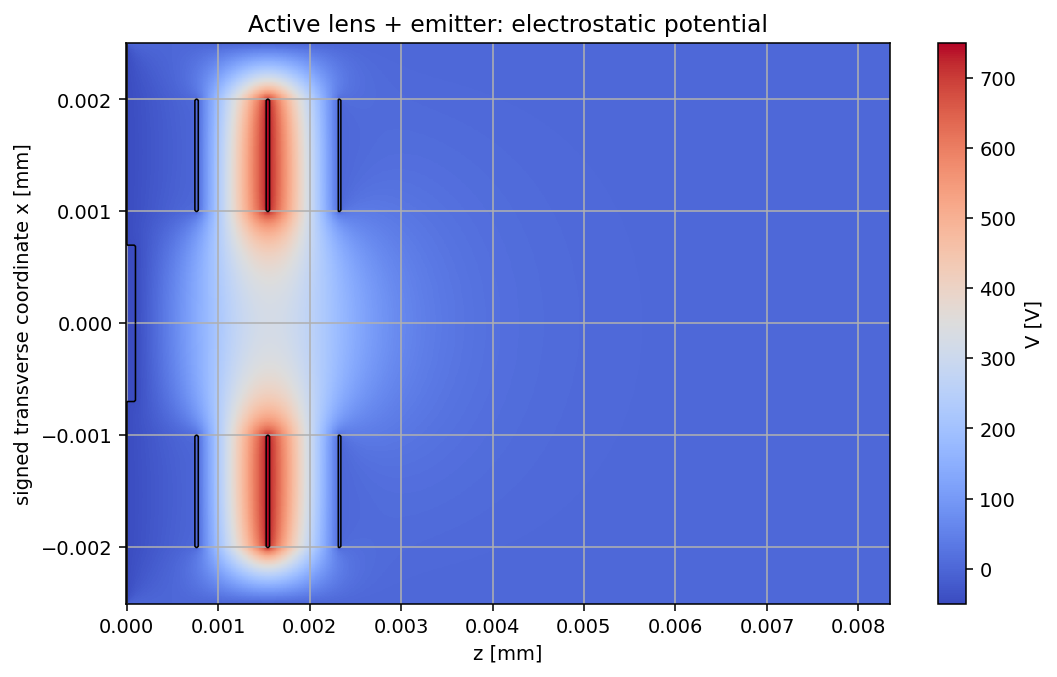

In [44]:
plot_device_preview(device, title="Active lens + emitter: electrostatic potential")
plt.show()

## 8. Step 2 — test that lens with trajectories

Edit only the launch/test settings below.  
The trajectory bundle is always constructed from the **active emitter dimensions** of the device built in Step 1.

In [45]:
# -----------------------------
# Trajectory test settings
# -----------------------------
n_rays = 15
#launch_mode = "emission_all_faces"   # "uniform_radius", "emission_quantiles", or "emission_all_faces"
launch_mode = "emission_quantiles"
initial_energy_eV = DEFAULT_INITIAL_ENERGY_EV
launch_half_angle_deg = DEFAULT_HALF_ANGLE_DEG
symmetric = True

n_subrays_per_face = 6  # publication-oriented default; see convergence study below
angle_mode = "gaussian"
angle_sigma_deg = 2.0
angle_max_deg = 8.0

energy_mode = "gaussian"
energy_sigma_eV = 0.10
energy_min_eV = 0.01

rng_seed = 12345

# Launch a few nm above the canopy to approximate near-surface emission.
z_offset_m = 5.0e-9
z_offset_fraction_of_forest_height = 0.20   # ignored when z_offset_m is set
z_offset_floor_m = 2.0e-9

lens_test = test_lens(
    device,
    n_rays=n_rays,
    mode=launch_mode,
    initial_energy_eV=initial_energy_eV,
    launch_half_angle_deg=launch_half_angle_deg,
    symmetric=symmetric,
    z_offset_m=z_offset_m,
    z_offset_fraction_of_forest_height=z_offset_fraction_of_forest_height,
    z_offset_floor_m=z_offset_floor_m,
    n_subrays_per_face=n_subrays_per_face,
    angle_mode=angle_mode,
    angle_sigma_deg=angle_sigma_deg,
    angle_max_deg=angle_max_deg,
    energy_mode=energy_mode,
    energy_sigma_eV=energy_sigma_eV,
    energy_min_eV=energy_min_eV,
    rng_seed=rng_seed,
)

launch_cfg = lens_test["launch_cfg"]
run_result = lens_test["run_result"]
summary_table = lens_test["summary_table"]
launch_table = lens_test["launch_table"]

print("Lens test completed.")
print("\nLaunch diagnostics:")
launch_table

Lens test completed.

Launch diagnostics:


,metric,value,unit
0,launch_mode,emission_quantiles,
1,n_launch_points,30,rays
2,sum_weights,3.000000e+01,arb.
3,min_x0,-6.876791e-01,µm
4,max_x0,6.876791e-01,µm
5,max_abs_x0,6.876791e-01,µm
6,min_z0,9.776974e+01,nm
7,max_z0,9.776974e+01,nm
8,mean_initial_energy_eV,2.330611e-01,eV
9,std_initial_energy_eV,1.154872e-01,eV


In [46]:
summary_table

,value
n_launch,30
n_top_exit,30
n_hit_conductor,0
n_turnaround,0
n_radial_exit,0
weight_launch,3.000000e+01
weight_top_exit,3.000000e+01
weight_hit_conductor,0.000000e+00
weight_turnaround,0.000000e+00
weight_radial_exit,0.000000e+00


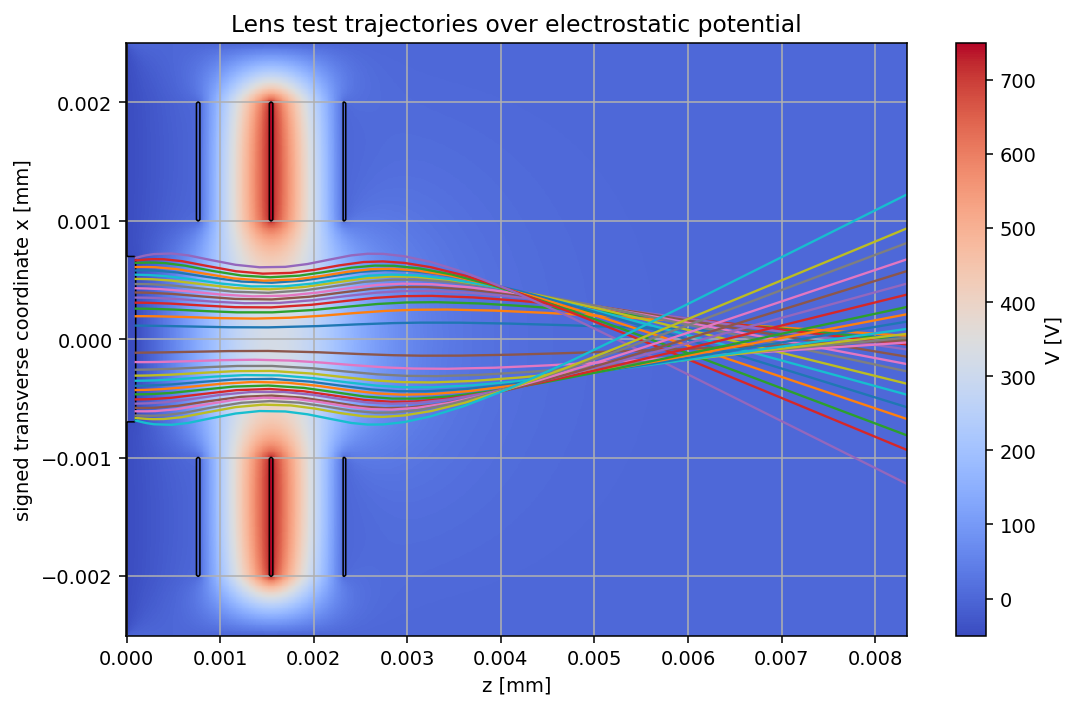

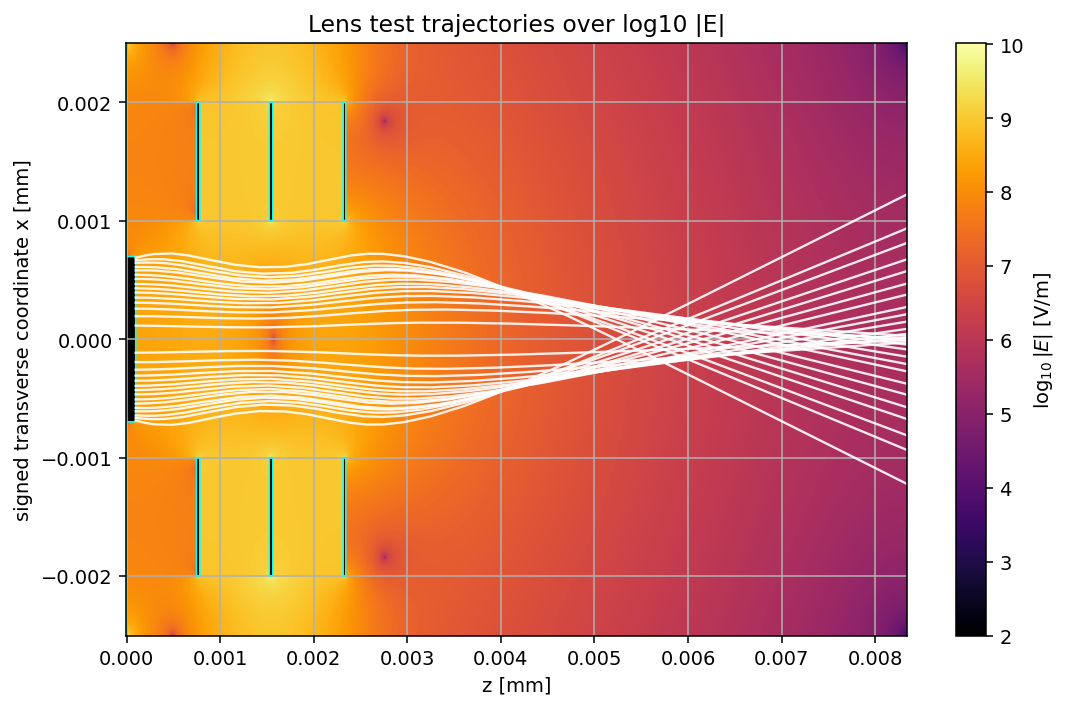

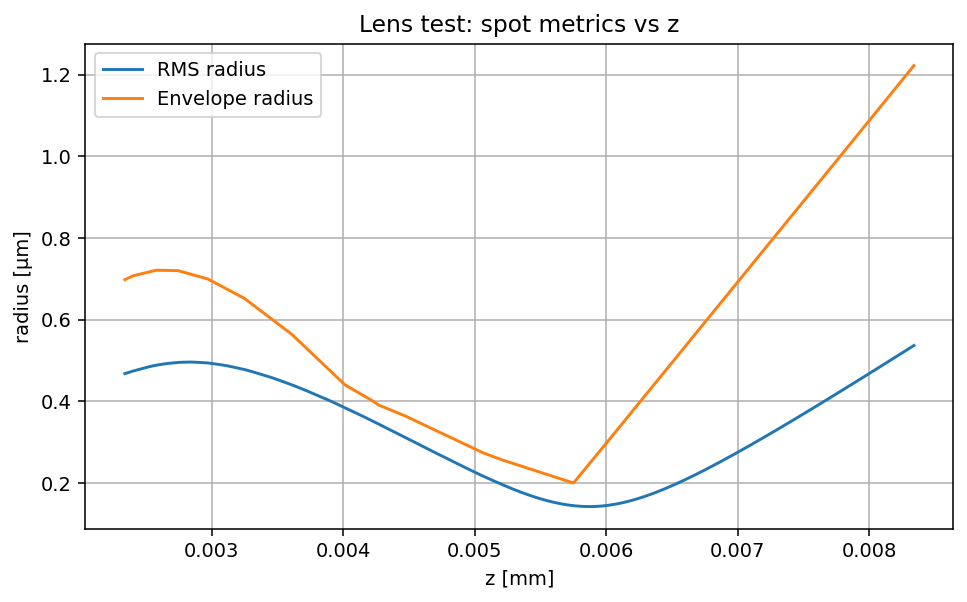

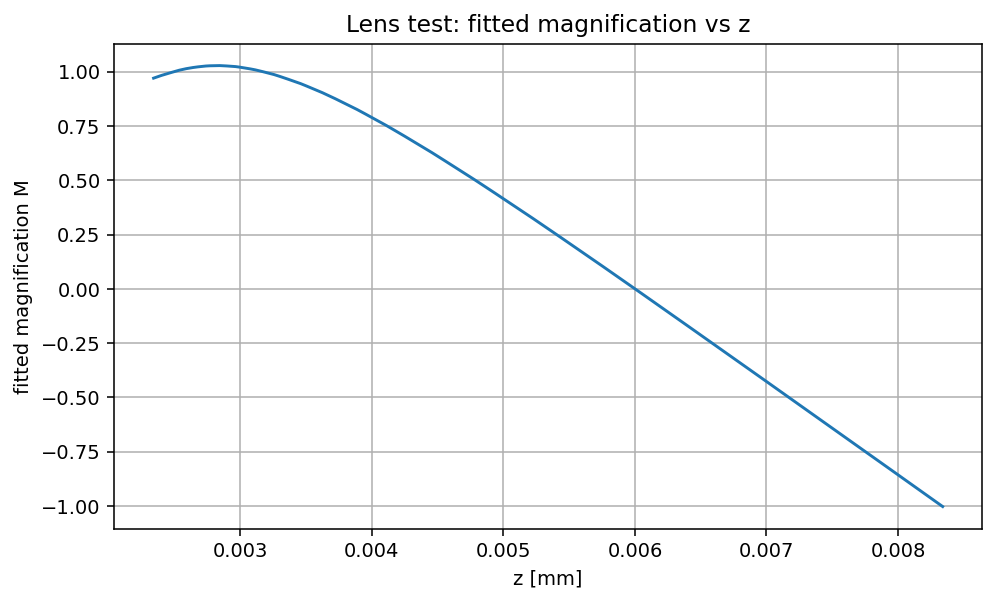

In [47]:
plot_trajectories_over_potential(
    run_result,
    title="Lens test trajectories over electrostatic potential",
)
plt.show()

plot_trajectories_over_field(
    run_result,
    title="Lens test trajectories over log10 |E|",
)
plt.show()

if run_result["beam_df"] is not None:
    plot_beam_metrics(run_result, title_prefix="Lens test")
    plt.show()

,scale,V_CNT_V,V_MID_V,initial_energy_eV,n_launch,n_top_exit,top_exit_frac,weight_top_exit_frac,spot_rms_um,focus_z_mm,m_fit_at_spot,edge_limited,z_focus_asym_mm,z_focus_asym_std_mm,mean_abs_exit_slope,max_energy_drift
0,2.500000e-01,3.750000e+02,5.000000e+03,2.000000e-01,252,246,9.761905e-01,1.000000e+00,5.662886e+00,2.664392e+00,-1.930446e-03,False,2.687455e+00,1.152766e-02,5.003029e-01,1.737045e-06
1,5.000000e-01,7.500000e+02,1.000000e+04,2.000000e-01,252,246,9.761905e-01,9.999991e-01,7.356833e+00,2.649373e+00,3.253960e-04,False,2.675210e+00,2.375344e-02,5.110401e-01,2.566671e-06
2,7.500000e-01,1.125000e+03,1.500000e+04,2.000000e-01,252,246,9.761905e-01,9.999817e-01,1.458627e+01,2.646368e+00,1.965360e-03,False,2.680028e+00,6.695769e-02,5.072276e-01,2.253702e-06
3,1.000000e+00,1.500000e+03,2.000000e+04,2.000000e-01,252,246,9.761905e-01,9.999238e-01,2.335432e+01,2.646368e+00,1.078613e-02,False,2.704744e+00,1.262951e-01,4.880049e-01,2.216078e-06
4,1.250000e+00,1.875000e+03,2.500000e+04,2.000000e-01,252,246,9.761905e-01,9.998336e-01,3.160675e+01,2.652375e+00,1.853025e-02,False,2.746234e+00,1.805421e-01,4.568411e-01,1.860516e-06
5,1.500000e+00,2.250000e+03,3.000000e+04,2.000000e-01,252,246,9.761905e-01,9.997377e-01,3.830236e+01,2.658383e+00,3.121454e-02,False,2.794119e+00,2.193628e-01,4.218351e-01,1.680427e-06
6,2.000000e+00,3.000000e+03,4.000000e+04,2.000000e-01,252,246,9.761905e-01,9.995878e-01,4.699107e+01,2.676405e+00,5.078436e-02,False,2.879628e+00,2.568614e-01,3.615729e-01,1.729668e-06


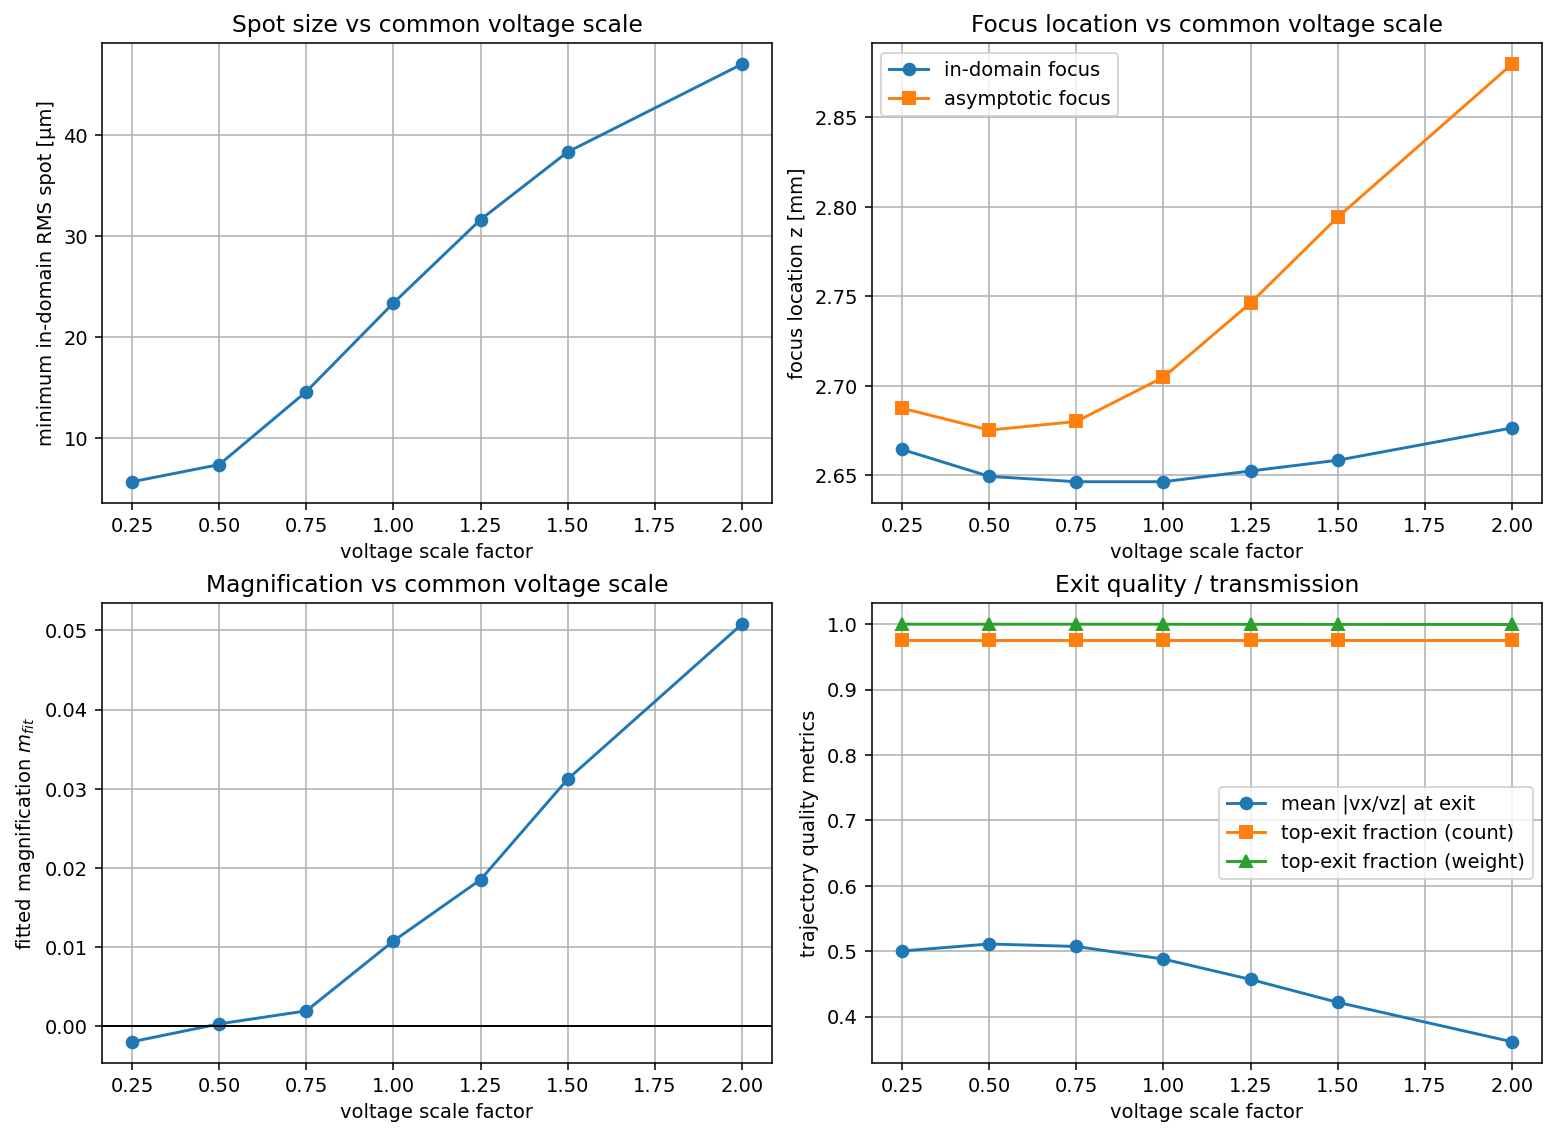

In [18]:
# Voltage-scale study: scale V_CNT and V_MID together by the same factor
# while keeping the geometry and the ratio V_MID / V_CNT fixed.

scale_factors = np.array([0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00], dtype=float)

# Set this True only if you want a true similarity-style study where the launch
# kinetic energy is also scaled with the voltages. Leave False to isolate how the
# absolute electrostatic scale changes the dynamics for the same injected beam.
scale_initial_energy = False

# Reuse the active device geometry / emitter / domain / grid
base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])
base_launch_kwargs = current_lens_test_kwargs()

rows = []
voltage_scale_runs = {}

for s in scale_factors:
    p = dict(base_params)
    p["V_CNT"] = float(base_params["V_CNT"] * s)
    p["V_MID"] = float(base_params["V_MID"] * s)

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=base_domain,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    this_launch_kwargs = dict(base_launch_kwargs)
    if scale_initial_energy:
        this_launch_kwargs["initial_energy_eV"] = float(base_launch_kwargs["initial_energy_eV"] * s)

    scaled_test = test_lens(
        scaled_device,
        **this_launch_kwargs,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    rows.append({
        "scale": float(s),
        "V_CNT_V": float(p["V_CNT"]),
        "V_MID_V": float(p["V_MID"]),
        "initial_energy_eV": float(this_launch_kwargs["initial_energy_eV"]),
        "n_launch": int(sm.get("n_launch", 0)),
        "n_top_exit": int(sm.get("n_top_exit", 0)),
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "weight_top_exit_frac": float(sm.get("weight_top_exit_frac", np.nan)),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "edge_limited": sm.get("in_domain_edge_limited", np.nan),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "z_focus_asym_std_mm": 1e3 * float(sm.get("z_focus_asym_std", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    })

    voltage_scale_runs[float(s)] = {
        "device": scaled_device,
        "test": scaled_test,
        "run_result": rr,
    }

voltage_scale_df = pd.DataFrame(rows).sort_values("scale").reset_index(drop=True)
display(voltage_scale_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(voltage_scale_df["scale"], voltage_scale_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel("voltage scale factor")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs common voltage scale")

axes[0, 1].plot(voltage_scale_df["scale"], voltage_scale_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(voltage_scale_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(voltage_scale_df["scale"], voltage_scale_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel("voltage scale factor")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs common voltage scale")
axes[0, 1].legend()

axes[1, 0].plot(voltage_scale_df["scale"], voltage_scale_df["m_fit_at_spot"], marker="o")
axes[1, 0].axhline(0.0, color="k", linewidth=1)
axes[1, 0].set_xlabel("voltage scale factor")
axes[1, 0].set_ylabel(r"fitted magnification $m_{fit}$")
axes[1, 0].set_title("Magnification vs common voltage scale")

axes[1, 1].plot(voltage_scale_df["scale"], voltage_scale_df["mean_abs_exit_slope"], marker="o", label="mean |vx/vz| at exit")
axes[1, 1].plot(voltage_scale_df["scale"], voltage_scale_df["top_exit_frac"], marker="s", label="top-exit fraction (count)")
if np.isfinite(voltage_scale_df["weight_top_exit_frac"]).any():
    axes[1, 1].plot(voltage_scale_df["scale"], voltage_scale_df["weight_top_exit_frac"], marker="^", label="top-exit fraction (weight)")
axes[1, 1].set_xlabel("voltage scale factor")
axes[1, 1].set_ylabel("trajectory quality metrics")
axes[1, 1].set_title("Exit quality / transmission")
axes[1, 1].legend()

plt.show()

,sep_scale,d1_um,d2_um,d3_um,z_extra_um,a_inner_um,R_forest_um,n_launch,n_top_exit,top_exit_frac,weight_top_exit_frac,spot_rms_um,focus_z_mm,m_fit_at_spot,edge_limited,z_focus_asym_mm,z_focus_asym_std_mm,mean_abs_exit_slope,max_energy_drift
0,1.000000e+00,3.500000e+02,4.500000e+02,4.500000e+02,2.400000e+03,5.000000e+02,3.000000e+02,252,246,9.761905e-01,9.999238e-01,2.335432e+01,2.646368e+00,1.078613e-02,False,2.704744e+00,1.262951e-01,4.880049e-01,2.216078e-06
1,1.200000e+00,4.200000e+02,5.400000e+02,5.400000e+02,2.880000e+03,5.000000e+02,3.000000e+02,252,246,9.761905e-01,9.999676e-01,2.878779e+00,2.902977e+00,5.861844e-04,False,2.921913e+00,1.500547e-02,3.780375e-01,1.796685e-06
2,1.400000e+00,4.900000e+02,6.300000e+02,6.300000e+02,3.360000e+03,5.000000e+02,3.000000e+02,252,246,9.761905e-01,9.999979e-01,6.243145e+00,2.924692e+00,-3.052154e-03,False,2.933716e+00,2.491243e-02,3.776575e-01,1.724311e-06
3,1.600000e+00,5.600000e+02,7.200000e+02,7.200000e+02,3.840000e+03,5.000000e+02,3.000000e+02,252,252,1.000000e+00,1.000000e+00,9.752462e+00,3.078573e+00,-3.268904e-03,False,3.080224e+00,4.468334e-02,3.162655e-01,2.301541e-06
4,1.800000e+00,6.300000e+02,8.100000e+02,8.100000e+02,4.320000e+03,5.000000e+02,3.000000e+02,252,244,9.682540e-01,1.000000e+00,6.660604e+00,3.139337e+00,1.704135e-03,False,3.142803e+00,3.226654e-02,3.208230e-01,2.020848e-06
5,2.000000e+00,7.000000e+02,9.000000e+02,9.000000e+02,4.800000e+03,5.000000e+02,3.000000e+02,252,240,9.523810e-01,1.000000e+00,4.966724e+00,3.166458e+00,1.585049e-03,False,3.167068e+00,2.583277e-02,3.102703e-01,2.182670e-06


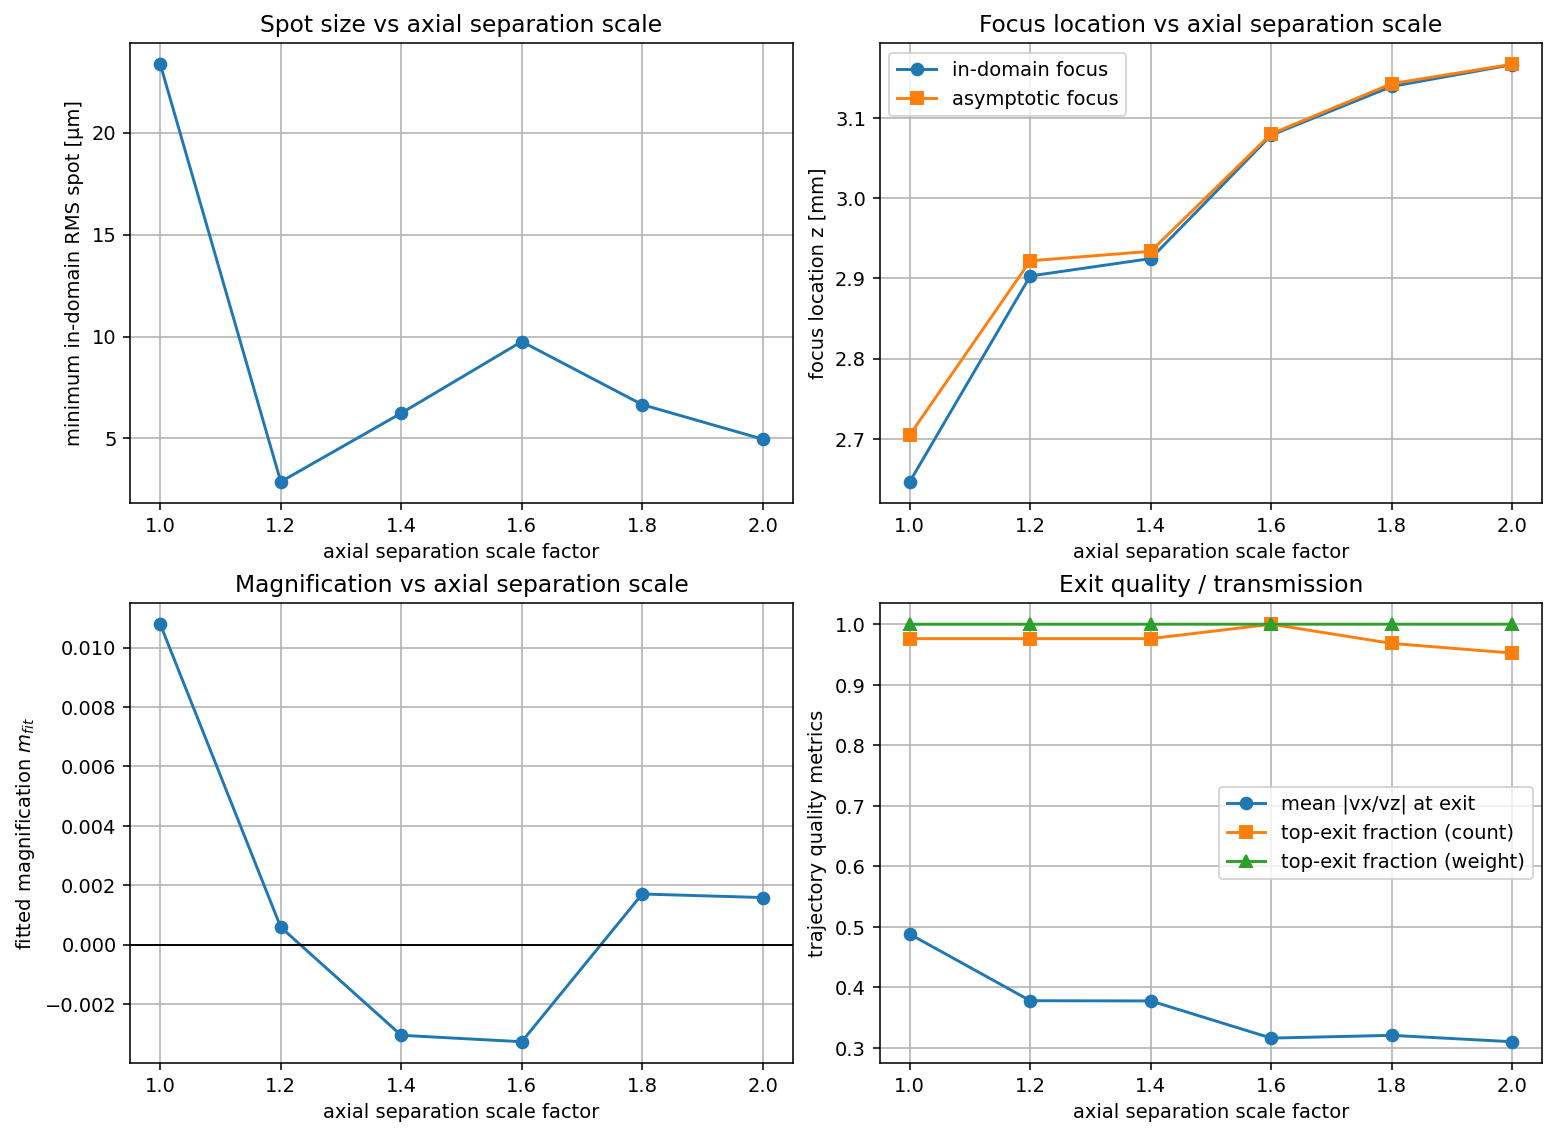

In [19]:
# Axial-separation study: scale the lens separations together
# while keeping the aperture radius and CNT forest radius fixed.

sep_scale_factors = np.array([1.00, 1.20, 1.40, 1.60, 1.80, 2.00], dtype=float)

base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])
base_launch_kwargs = current_lens_test_kwargs()

rows = []
axial_scale_runs = {}

for s in sep_scale_factors:
    p = dict(base_params)
    dom = dict(base_domain)

    p["d1"] = float(base_params["d1"] * s)
    p["d2"] = float(base_params["d2"] * s)
    p["d3"] = float(base_params["d3"] * s)
    dom["z_extra"] = float(base_domain["z_extra"] * s)

    p["a_inner"] = float(base_params["a_inner"])
    p["R_forest"] = float(base_params["R_forest"])

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    this_launch_kwargs = dict(base_launch_kwargs)
    if this_launch_kwargs["z_offset_m"] is not None:
        this_launch_kwargs["z_offset_m"] = float(this_launch_kwargs["z_offset_m"] * s)

    scaled_test = test_lens(
        scaled_device,
        **this_launch_kwargs,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    rows.append({
        "sep_scale": float(s),
        "d1_um": 1e6 * float(p["d1"]),
        "d2_um": 1e6 * float(p["d2"]),
        "d3_um": 1e6 * float(p["d3"]),
        "z_extra_um": 1e6 * float(dom["z_extra"]),
        "a_inner_um": 1e6 * float(p["a_inner"]),
        "R_forest_um": 1e6 * float(p["R_forest"]),
        "n_launch": int(sm.get("n_launch", 0)),
        "n_top_exit": int(sm.get("n_top_exit", 0)),
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "weight_top_exit_frac": float(sm.get("weight_top_exit_frac", np.nan)),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "edge_limited": sm.get("in_domain_edge_limited", np.nan),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "z_focus_asym_std_mm": 1e3 * float(sm.get("z_focus_asym_std", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    })

    axial_scale_runs[float(s)] = {
        "device": scaled_device,
        "test": scaled_test,
        "run_result": rr,
    }

axial_scale_df = pd.DataFrame(rows).sort_values("sep_scale").reset_index(drop=True)
display(axial_scale_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(axial_scale_df["sep_scale"], axial_scale_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel("axial separation scale factor")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs axial separation scale")

axes[0, 1].plot(axial_scale_df["sep_scale"], axial_scale_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(axial_scale_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(axial_scale_df["sep_scale"], axial_scale_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel("axial separation scale factor")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs axial separation scale")
axes[0, 1].legend()

axes[1, 0].plot(axial_scale_df["sep_scale"], axial_scale_df["m_fit_at_spot"], marker="o")
axes[1, 0].axhline(0.0, color="k", linewidth=1)
axes[1, 0].set_xlabel("axial separation scale factor")
axes[1, 0].set_ylabel(r"fitted magnification $m_{fit}$")
axes[1, 0].set_title("Magnification vs axial separation scale")

axes[1, 1].plot(axial_scale_df["sep_scale"], axial_scale_df["mean_abs_exit_slope"], marker="o", label="mean |vx/vz| at exit")
axes[1, 1].plot(axial_scale_df["sep_scale"], axial_scale_df["top_exit_frac"], marker="s", label="top-exit fraction (count)")
if np.isfinite(axial_scale_df["weight_top_exit_frac"]).any():
    axes[1, 1].plot(axial_scale_df["sep_scale"], axial_scale_df["weight_top_exit_frac"], marker="^", label="top-exit fraction (weight)")
axes[1, 1].set_xlabel("axial separation scale factor")
axes[1, 1].set_ylabel("trajectory quality metrics")
axes[1, 1].set_title("Exit quality / transmission")
axes[1, 1].legend()

plt.show()

,radial_scale,axial_hold_scale,a_inner_um,r_stack_outer_um,R_forest_um,edge_radius_nm,forest_edge_radius_nm,emission_edge_exclusion_um,R_outer_um,d1_um,...,weight_top_exit_frac,spot_rms_um,focus_z_mm,m_fit_at_spot,edge_limited,z_focus_asym_mm,z_focus_asym_std_mm,mean_abs_exit_slope,max_energy_drift,status
0,6.000000e-01,1.200000e+00,3.000000e+02,6.600000e+02,1.800000e+02,1.800000e+04,1.200000e+04,1.500000e+01,9.600000e+02,4.200000e+02,...,8.460297e-01,2.343520e+00,1.958598e+00,-2.656379e-03,False,1.957037e+00,7.911090e-03,3.368088e-01,3.744891e-06,ok
1,8.000000e-01,1.200000e+00,4.000000e+02,8.800000e+02,2.400000e+02,2.400000e+04,1.600000e+04,2.000000e+01,1.280000e+03,4.200000e+02,...,9.999985e-01,6.971799e+00,2.430787e+00,-1.628695e-03,False,2.434163e+00,2.852036e-02,3.597897e-01,1.807046e-06,ok
2,1.000000e+00,1.200000e+00,5.000000e+02,1.100000e+03,3.000000e+02,3.000000e+04,2.000000e+04,2.500000e+01,1.600000e+03,4.200000e+02,...,9.999676e-01,2.877463e+00,2.902977e+00,5.600779e-04,False,2.921893e+00,1.500549e-02,3.780631e-01,1.849216e-06,ok
3,1.200000e+00,1.200000e+00,6.000000e+02,1.320000e+03,3.600000e+02,3.600000e+04,2.400000e+04,3.000000e+01,1.920000e+03,4.200000e+02,...,9.998855e-01,1.888578e+01,3.382375e+00,4.061968e-03,False,3.439667e+00,1.465518e-01,3.856089e-01,2.261079e-06,ok
4,1.400000e+00,1.200000e+00,7.000000e+02,1.540000e+03,4.200000e+02,4.200000e+04,2.800000e+04,3.500000e+01,2.240000e+03,4.200000e+02,...,9.984394e-01,6.765368e+01,4.679995e+00,4.859814e-02,True,5.438184e+00,8.068662e-01,1.313537e-01,1.146431e-06,ok
5,1.600000e+00,1.200000e+00,8.000000e+02,1.760000e+03,4.800000e+02,4.800000e+04,3.200000e+04,4.000000e+01,2.560000e+03,4.200000e+02,...,9.981642e-01,2.453071e+02,4.679995e+00,1.010132e+00,True,1.039653e+01,3.049794e+00,5.882886e-02,5.967764e-07,ok


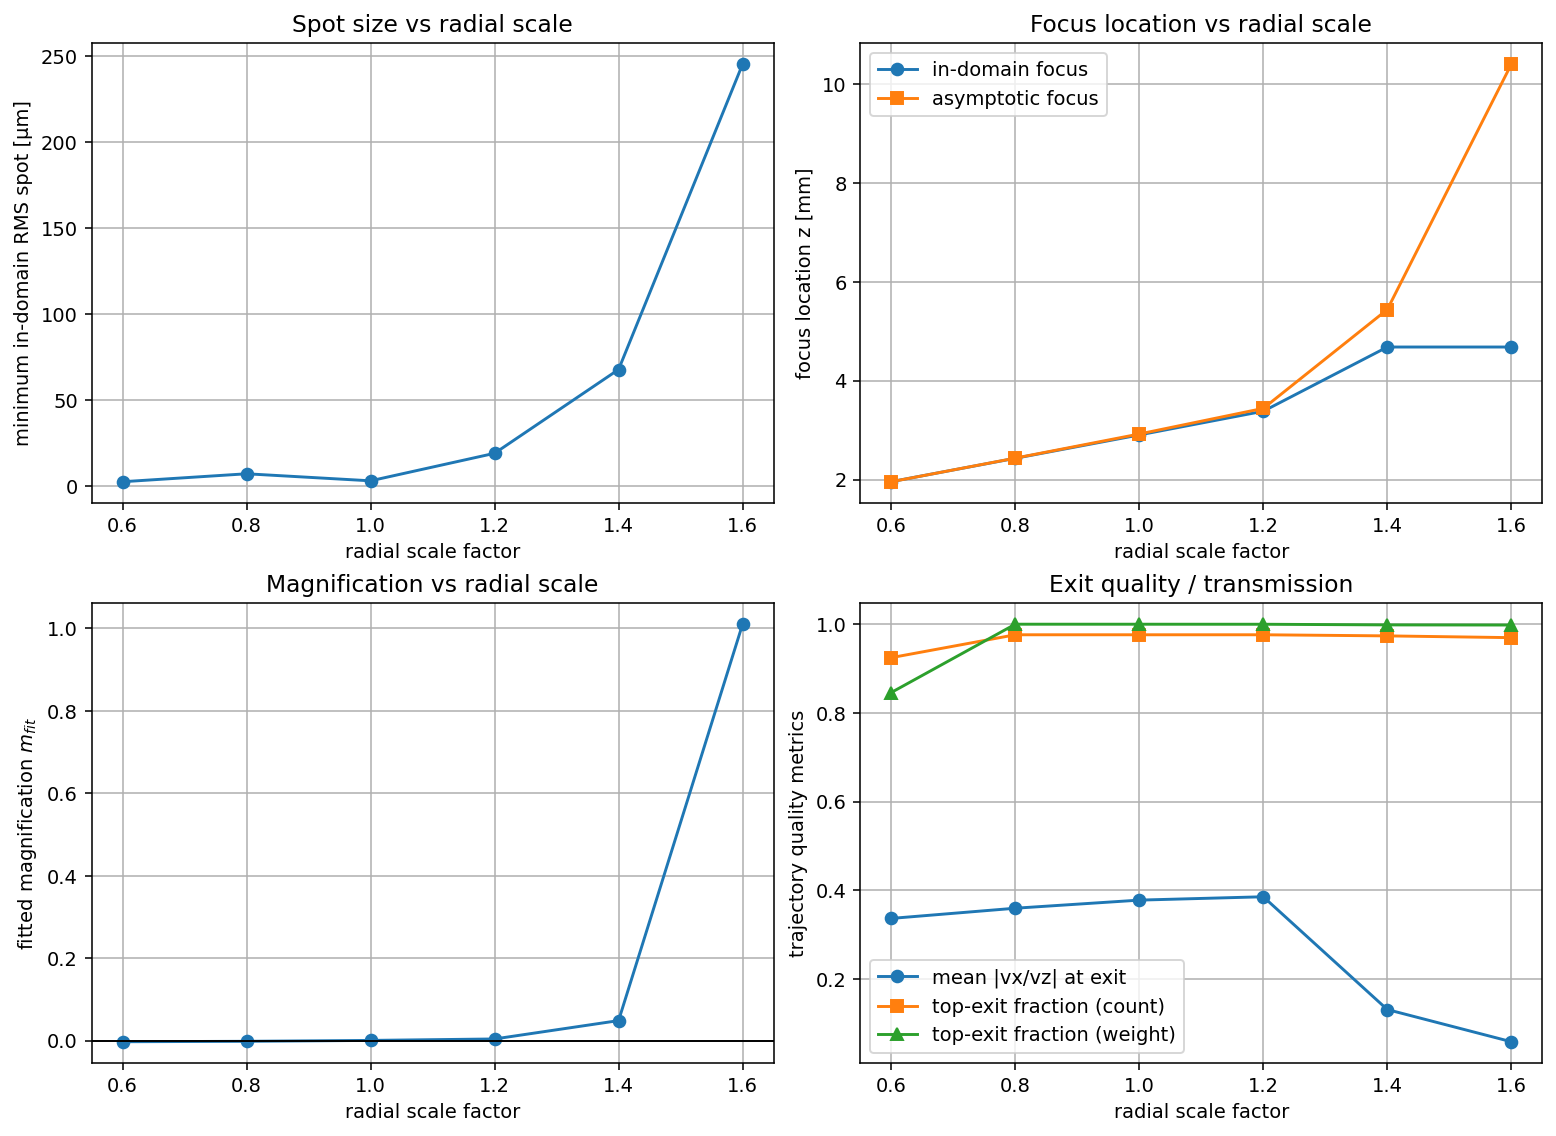

In [20]:
# Radial-geometry study:
# - Hold all axial separations at the best-performing 1.2x scale
# - Scale the radial geometry together by a common factor
# - Keep voltages and launch physics otherwise unchanged

radial_scale_factors = np.array([0.60, 0.80, 1.00, 1.20, 1.40, 1.60], dtype=float)
axial_hold_scale = 1.20

base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])
base_launch_kwargs = current_lens_test_kwargs()

rows = []
radial_scale_runs = {}

for s in radial_scale_factors:
    p = dict(base_params)
    dom = dict(base_domain)

    p["d1"] = float(base_params["d1"] * axial_hold_scale)
    p["d2"] = float(base_params["d2"] * axial_hold_scale)
    p["d3"] = float(base_params["d3"] * axial_hold_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_hold_scale)

    radial_keys = [
        "a_inner",
        "r_stack_outer",
        "R_forest",
        "edge_radius",
        "forest_edge_radius",
        "emission_edge_exclusion",
    ]
    for key in radial_keys:
        if key in p:
            p[key] = float(base_params[key] * s)

    dom["R_outer"] = float(base_domain["R_outer"] * s)

    note = ""
    invalid = False

    if "R_forest" in p and "emission_edge_exclusion" in p:
        if p["R_forest"] <= p["emission_edge_exclusion"]:
            invalid = True
            note = "invalid: R_forest <= emission_edge_exclusion"

    if "a_inner" in p and "r_stack_outer" in p:
        if p["a_inner"] >= p["r_stack_outer"]:
            invalid = True
            note = "invalid: a_inner >= r_stack_outer"

    if invalid:
        rows.append({
            "radial_scale": float(s),
            "axial_hold_scale": float(axial_hold_scale),
            "a_inner_um": 1e6 * float(p.get("a_inner", np.nan)),
            "r_stack_outer_um": 1e6 * float(p.get("r_stack_outer", np.nan)),
            "R_forest_um": 1e6 * float(p.get("R_forest", np.nan)),
            "edge_radius_nm": 1e9 * float(p.get("edge_radius", np.nan)),
            "forest_edge_radius_nm": 1e9 * float(p.get("forest_edge_radius", np.nan)),
            "emission_edge_exclusion_um": 1e6 * float(p.get("emission_edge_exclusion", np.nan)),
            "R_outer_um": 1e6 * float(dom.get("R_outer", np.nan)),
            "d1_um": 1e6 * float(p["d1"]),
            "d2_um": 1e6 * float(p["d2"]),
            "d3_um": 1e6 * float(p["d3"]),
            "z_extra_um": 1e6 * float(dom["z_extra"]),
            "status": note,
        })
        continue

    try:
        scaled_device = create_lens_emitter(
            p,
            domain_overrides=dom,
            rebuild_grid=base_grid,
            allow_cached_baseline=False,
        )

        this_launch_kwargs = dict(base_launch_kwargs)
        scaled_test = test_lens(
            scaled_device,
            **this_launch_kwargs,
        )

        rr = scaled_test["run_result"]
        sm = rr["summary"]

        ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
        if len(ok) > 0:
            slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
            w = ok["weight"].to_numpy()
            mean_abs_exit_slope = float(np.average(slopes, weights=w))
        else:
            mean_abs_exit_slope = np.nan

        launch_radius_um = np.nan
        if "bundle_df" in rr and "x0" in rr["bundle_df"].columns:
            launch_radius_um = 1e6 * float(rr["bundle_df"]["x0"].abs().max())

        rows.append({
            "radial_scale": float(s),
            "axial_hold_scale": float(axial_hold_scale),
            "a_inner_um": 1e6 * float(p["a_inner"]),
            "r_stack_outer_um": 1e6 * float(p["r_stack_outer"]),
            "R_forest_um": 1e6 * float(p["R_forest"]),
            "edge_radius_nm": 1e9 * float(p["edge_radius"]),
            "forest_edge_radius_nm": 1e9 * float(p["forest_edge_radius"]),
            "emission_edge_exclusion_um": 1e6 * float(p["emission_edge_exclusion"]),
            "R_outer_um": 1e6 * float(dom["R_outer"]),
            "d1_um": 1e6 * float(p["d1"]),
            "d2_um": 1e6 * float(p["d2"]),
            "d3_um": 1e6 * float(p["d3"]),
            "z_extra_um": 1e6 * float(dom["z_extra"]),
            "launch_radius_um": launch_radius_um,
            "n_launch": int(sm.get("n_launch", 0)),
            "n_top_exit": int(sm.get("n_top_exit", 0)),
            "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
            "weight_top_exit_frac": float(sm.get("weight_top_exit_frac", np.nan)),
            "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
            "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
            "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
            "edge_limited": sm.get("in_domain_edge_limited", np.nan),
            "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
            "z_focus_asym_std_mm": 1e3 * float(sm.get("z_focus_asym_std", np.nan)),
            "mean_abs_exit_slope": mean_abs_exit_slope,
            "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
            "status": "ok",
        })

        radial_scale_runs[float(s)] = {
            "device": scaled_device,
            "test": scaled_test,
            "run_result": rr,
        }

    except Exception as exc:
        rows.append({
            "radial_scale": float(s),
            "axial_hold_scale": float(axial_hold_scale),
            "a_inner_um": 1e6 * float(p.get("a_inner", np.nan)),
            "r_stack_outer_um": 1e6 * float(p.get("r_stack_outer", np.nan)),
            "R_forest_um": 1e6 * float(p.get("R_forest", np.nan)),
            "edge_radius_nm": 1e9 * float(p.get("edge_radius", np.nan)),
            "forest_edge_radius_nm": 1e9 * float(p.get("forest_edge_radius", np.nan)),
            "emission_edge_exclusion_um": 1e6 * float(p.get("emission_edge_exclusion", np.nan)),
            "R_outer_um": 1e6 * float(dom.get("R_outer", np.nan)),
            "d1_um": 1e6 * float(p["d1"]),
            "d2_um": 1e6 * float(p["d2"]),
            "d3_um": 1e6 * float(p["d3"]),
            "z_extra_um": 1e6 * float(dom["z_extra"]),
            "status": f"error: {exc}",
        })

radial_scale_df = pd.DataFrame(rows).sort_values("radial_scale").reset_index(drop=True)
display(radial_scale_df)

ok_df = radial_scale_df[radial_scale_df["status"] == "ok"].copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(ok_df["radial_scale"], ok_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel("radial scale factor")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs radial scale")

axes[0, 1].plot(ok_df["radial_scale"], ok_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(ok_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(ok_df["radial_scale"], ok_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel("radial scale factor")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs radial scale")
axes[0, 1].legend()

axes[1, 0].plot(ok_df["radial_scale"], ok_df["m_fit_at_spot"], marker="o")
axes[1, 0].axhline(0.0, color="k", linewidth=1)
axes[1, 0].set_xlabel("radial scale factor")
axes[1, 0].set_ylabel(r"fitted magnification $m_{fit}$")
axes[1, 0].set_title("Magnification vs radial scale")

axes[1, 1].plot(ok_df["radial_scale"], ok_df["mean_abs_exit_slope"], marker="o", label="mean |vx/vz| at exit")
axes[1, 1].plot(ok_df["radial_scale"], ok_df["top_exit_frac"], marker="s", label="top-exit fraction (count)")
if np.isfinite(ok_df["weight_top_exit_frac"]).any():
    axes[1, 1].plot(ok_df["radial_scale"], ok_df["weight_top_exit_frac"], marker="^", label="top-exit fraction (weight)")
axes[1, 1].set_xlabel("radial scale factor")
axes[1, 1].set_ylabel("trajectory quality metrics")
axes[1, 1].set_title("Exit quality / transmission")
axes[1, 1].legend()

plt.show()

In [21]:
# Study 1: voltage-ratio sweep at fixed 1.2 axial geometry
# V_CNT is held fixed; V_MID is varied through the ratio V_MID / V_CNT.

ratio_values = np.array([0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00, 3.00], dtype=float)
axial_hold_scale = 1.20

base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])
base_launch_kwargs = current_lens_test_kwargs()

rows = []
ratio_runs = {}

for ratio in ratio_values:
    p = dict(base_params)
    dom = dict(base_domain)

    p["d1"] = float(base_params["d1"] * axial_hold_scale)
    p["d2"] = float(base_params["d2"] * axial_hold_scale)
    p["d3"] = float(base_params["d3"] * axial_hold_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_hold_scale)

    p["V_CNT"] = float(base_params["V_CNT"])
    p["V_MID"] = float(p["V_MID"] * ratio)

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    scaled_test = test_lens(
        scaled_device,
        **base_launch_kwargs,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    rows.append({
        "Vmid_over_Vcnt": float(ratio),
        "V_CNT_V": float(p["V_CNT"]),
        "V_MID_V": float(p["V_MID"]),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "weight_top_exit_frac": float(sm.get("weight_top_exit_frac", np.nan)),
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    })

    ratio_runs[float(ratio)] = rr

voltage_ratio_df = pd.DataFrame(rows).sort_values("Vmid_over_Vcnt").reset_index(drop=True)
display(voltage_ratio_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel(r"$V_{\mathrm{MID}} / V_{\mathrm{CNT}}$")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs voltage ratio")

axes[0, 1].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(voltage_ratio_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel(r"$V_{\mathrm{MID}} / V_{\mathrm{CNT}}$")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs voltage ratio")
axes[0, 1].legend()

axes[1, 0].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["m_fit_at_spot"], marker="o")
axes[1, 0].axhline(0.0, color="k", linewidth=1)
axes[1, 0].set_xlabel(r"$V_{\mathrm{MID}} / V_{\mathrm{CNT}}$")
axes[1, 0].set_ylabel(r"fitted magnification $m_{fit}$")
axes[1, 0].set_title("Magnification vs voltage ratio")

axes[1, 1].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["mean_abs_exit_slope"], marker="o", label="mean |vx/vz| at exit")
axes[1, 1].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["top_exit_frac"], marker="s", label="top-exit fraction (count)")
if np.isfinite(voltage_ratio_df["weight_top_exit_frac"]).any():
    axes[1, 1].plot(voltage_ratio_df["Vmid_over_Vcnt"], voltage_ratio_df["weight_top_exit_frac"], marker="^", label="top-exit fraction (weight)")
axes[1, 1].set_xlabel(r"$V_{\mathrm{MID}} / V_{\mathrm{CNT}}$")
axes[1, 1].set_ylabel("trajectory quality metrics")
axes[1, 1].set_title("Exit quality / transmission")
axes[1, 1].legend()

plt.show()

ValueError: `ts` must be strictly increasing or decreasing.

In [ ]:
# Study 2: emitter fill-factor sweep at fixed 1.2 axial geometry
# Vary the usable emitting radius relative to the aperture:
# fill_factor = (R_forest - emission_edge_exclusion) / a_inner

fill_factors = np.array([0.20, 0.35, 0.50, 0.65, 0.80, 0.90], dtype=float)
axial_hold_scale = 1.20

base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])
base_launch_kwargs = current_lens_test_kwargs()

rows = []
fill_factor_runs = {}

for ff in fill_factors:
    p = dict(base_params)
    dom = dict(base_domain)

    p["d1"] = float(base_params["d1"] * axial_hold_scale)
    p["d2"] = float(base_params["d2"] * axial_hold_scale)
    p["d3"] = float(base_params["d3"] * axial_hold_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_hold_scale)

    a_inner = float(base_params["a_inner"])
    exclusion = float(base_params.get("emission_edge_exclusion", 0.0))
    usable_radius = float(ff * a_inner)
    p["R_forest"] = float(usable_radius + exclusion)

    if p["R_forest"] >= p["a_inner"]:
        rows.append({
            "fill_factor": float(ff),
            "a_inner_um": 1e6 * a_inner,
            "R_forest_um": 1e6 * p["R_forest"],
            "usable_emit_radius_um": 1e6 * usable_radius,
            "status": "invalid: R_forest >= a_inner",
        })
        continue

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    scaled_test = test_lens(
        scaled_device,
        **base_launch_kwargs,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    launch_radius_um = np.nan
    if "bundle_df" in rr and "x0" in rr["bundle_df"].columns:
        launch_radius_um = 1e6 * float(rr["bundle_df"]["x0"].abs().max())

    rows.append({
        "fill_factor": float(ff),
        "a_inner_um": 1e6 * a_inner,
        "R_forest_um": 1e6 * float(p["R_forest"]),
        "usable_emit_radius_um": 1e6 * usable_radius,
        "launch_radius_um": launch_radius_um,
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "weight_top_exit_frac": float(sm.get("weight_top_exit_frac", np.nan)),
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
        "status": "ok",
    })

    fill_factor_runs[float(ff)] = rr

fill_factor_df = pd.DataFrame(rows).sort_values("fill_factor").reset_index(drop=True)
display(fill_factor_df)

ok_df = fill_factor_df[fill_factor_df["status"] == "ok"].copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(ok_df["fill_factor"], ok_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel("usable emitter fill factor")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs emitter fill factor")

axes[0, 1].plot(ok_df["fill_factor"], ok_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(ok_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(ok_df["fill_factor"], ok_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel("usable emitter fill factor")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs emitter fill factor")
axes[0, 1].legend()

axes[1, 0].plot(ok_df["fill_factor"], ok_df["m_fit_at_spot"], marker="o")
axes[1, 0].axhline(0.0, color="k", linewidth=1)
axes[1, 0].set_xlabel("usable emitter fill factor")
axes[1, 0].set_ylabel(r"fitted magnification $m_{fit}$")
axes[1, 0].set_title("Magnification vs emitter fill factor")

axes[1, 1].plot(ok_df["fill_factor"], ok_df["mean_abs_exit_slope"], marker="o", label="mean |vx/vz| at exit")
axes[1, 1].plot(ok_df["fill_factor"], ok_df["top_exit_frac"], marker="s", label="top-exit fraction (count)")
if np.isfinite(ok_df["weight_top_exit_frac"]).any():
    axes[1, 1].plot(ok_df["fill_factor"], ok_df["weight_top_exit_frac"], marker="^", label="top-exit fraction (weight)")
axes[1, 1].set_xlabel("usable emitter fill factor")
axes[1, 1].set_ylabel("trajectory quality metrics")
axes[1, 1].set_title("Exit quality / transmission")
axes[1, 1].legend()

plt.show()

In [ ]:
# Study 3: injected initial-energy sweep at fixed 1.2 axial geometry

initial_energy_values_eV = np.array([0.01, 0.05, 0.10, 0.20, 0.50, 1.00, 2.00, 5.00], dtype=float)
axial_hold_scale = 1.20

base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])
base_launch_kwargs = current_lens_test_kwargs()

rows = []
energy_runs = {}

for E0 in initial_energy_values_eV:
    p = dict(base_params)
    dom = dict(base_domain)

    p["d1"] = float(base_params["d1"] * axial_hold_scale)
    p["d2"] = float(base_params["d2"] * axial_hold_scale)
    p["d3"] = float(base_params["d3"] * axial_hold_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_hold_scale)

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    this_launch_kwargs = dict(base_launch_kwargs)
    this_launch_kwargs["energy_mode"] = "delta"
    this_launch_kwargs["initial_energy_eV"] = float(E0)

    scaled_test = test_lens(
        scaled_device,
        **this_launch_kwargs,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    rows.append({
        "initial_energy_eV": float(E0),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "weight_top_exit_frac": float(sm.get("weight_top_exit_frac", np.nan)),
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    })

    energy_runs[float(E0)] = rr

energy_sweep_df = pd.DataFrame(rows).sort_values("initial_energy_eV").reset_index(drop=True)
display(energy_sweep_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["spot_rms_um"], marker="o")
axes[0, 0].set_xscale("log")
axes[0, 0].set_xlabel("initial energy [eV]")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Spot size vs initial energy")

axes[0, 1].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(energy_sweep_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xscale("log")
axes[0, 1].set_xlabel("initial energy [eV]")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Focus location vs initial energy")
axes[0, 1].legend()

axes[1, 0].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["m_fit_at_spot"], marker="o")
axes[1, 0].axhline(0.0, color="k", linewidth=1)
axes[1, 0].set_xscale("log")
axes[1, 0].set_xlabel("initial energy [eV]")
axes[1, 0].set_ylabel(r"fitted magnification $m_{fit}$")
axes[1, 0].set_title("Magnification vs initial energy")

axes[1, 1].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["mean_abs_exit_slope"], marker="o", label="mean |vx/vz| at exit")
axes[1, 1].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["top_exit_frac"], marker="s", label="top-exit fraction (count)")
if np.isfinite(energy_sweep_df["weight_top_exit_frac"]).any():
    axes[1, 1].plot(energy_sweep_df["initial_energy_eV"], energy_sweep_df["weight_top_exit_frac"], marker="^", label="top-exit fraction (weight)")
axes[1, 1].set_xscale("log")
axes[1, 1].set_xlabel("initial energy [eV]")
axes[1, 1].set_ylabel("trajectory quality metrics")
axes[1, 1].set_title("Exit quality / transmission")
axes[1, 1].legend()

plt.show()

In [ ]:
# Study 4: d1-only sweep around the 1.2x axial baseline
# d2, d3, and z_extra stay at the 1.2x baseline values.

d1_scale_values = np.array([0.50, 0.75, 1.00, 1.25, 1.50, 2.00], dtype=float)
axial_hold_scale = 1.20

base_params = {k: device["params"][k] for k in EXPLICIT_PARAM_KEYS}
base_domain = dict(device["domain"])
base_grid = tuple(device["grid"])
base_launch_kwargs = current_lens_test_kwargs()

d1_baseline = float(base_params["d1"] * axial_hold_scale)

rows = []
d1_runs = {}

for s in d1_scale_values:
    p = dict(base_params)
    dom = dict(base_domain)

    p["d2"] = float(base_params["d2"] * axial_hold_scale)
    p["d3"] = float(base_params["d3"] * axial_hold_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_hold_scale)

    p["d1"] = float(d1_baseline * s)

    scaled_device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )

    scaled_test = test_lens(
        scaled_device,
        **base_launch_kwargs,
    )

    rr = scaled_test["run_result"]
    sm = rr["summary"]

    ok = rr["summary_df"][rr["summary_df"]["stop_reason"] == "top_exit"].copy()
    if len(ok) > 0:
        slopes = np.abs(ok["vx_end"].to_numpy() / ok["vz_end"].to_numpy())
        w = ok["weight"].to_numpy()
        mean_abs_exit_slope = float(np.average(slopes, weights=w))
    else:
        mean_abs_exit_slope = np.nan

    rows.append({
        "d1_scale_about_1p2x": float(s),
        "d1_um": 1e6 * float(p["d1"]),
        "d2_um": 1e6 * float(p["d2"]),
        "d3_um": 1e6 * float(p["d3"]),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope,
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "weight_top_exit_frac": float(sm.get("weight_top_exit_frac", np.nan)),
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    })

    d1_runs[float(s)] = rr

d1_sweep_df = pd.DataFrame(rows).sort_values("d1_scale_about_1p2x").reset_index(drop=True)
display(d1_sweep_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["spot_rms_um"], marker="o")
axes[0, 0].set_xlabel(r"$d_1$ scale about baseline")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title(r"Spot size vs $d_1$")

axes[0, 1].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["focus_z_mm"], marker="o", label="in-domain focus")
if np.isfinite(d1_sweep_df["z_focus_asym_mm"]).any():
    axes[0, 1].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
axes[0, 1].set_xlabel(r"$d_1$ scale about baseline")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title(r"Focus location vs $d_1$")
axes[0, 1].legend()

axes[1, 0].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["m_fit_at_spot"], marker="o")
axes[1, 0].axhline(0.0, color="k", linewidth=1)
axes[1, 0].set_xlabel(r"$d_1$ scale about baseline")
axes[1, 0].set_ylabel(r"fitted magnification $m_{fit}$")
axes[1, 0].set_title(r"Magnification vs $d_1$")

axes[1, 1].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["mean_abs_exit_slope"], marker="o", label="mean |vx/vz| at exit")
axes[1, 1].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["top_exit_frac"], marker="s", label="top-exit fraction (count)")
if np.isfinite(d1_sweep_df["weight_top_exit_frac"]).any():
    axes[1, 1].plot(d1_sweep_df["d1_scale_about_1p2x"], d1_sweep_df["weight_top_exit_frac"], marker="^", label="top-exit fraction (weight)")
axes[1, 1].set_xlabel(r"$d_1$ scale about baseline")
axes[1, 1].set_ylabel("trajectory quality metrics")
axes[1, 1].set_title(r"Exit quality / transmission vs $d_1$")
axes[1, 1].legend()

plt.show()

## 9. Notes for manual studies

- To change the **device physics**, edit **Step 1** and rerun the build cell.
- To keep the same device but change only the **trajectory test**, edit **Step 2** and rerun only the test cells.
- The active launch radius is always:

  \[
  r_{\max,\mathrm{launch}} = R_{\mathrm{forest}} - \texttt{emission\_edge\_exclusion}.
  \]

That makes it easy to verify whether the launched bundle is actually compatible with the emitter you specified.

## 9A. Runtime optimization notes

The publication-closure studies below now reuse cached electrostatic builds, cache repeated publication runs, avoid building full trajectory DataFrames for sweep-only jobs, and keep full solution objects only for top-exit rays unless a plot explicitly needs the full paths. This preserves the beam metrics used in the paper while reducing repeated solve and memory overhead.

## 9. Publication-grade closure studies and figure export

The cells below add the pieces that most improve the manuscript from a strong draft to a more review-resistant paper:

1. **publication figure / table export** to `publication_figures/`,
2. an **extended \(d_1\)** sweep that brackets the high-\(d_1\) optimum instead of stopping at the previous boundary,
3. a **trajectory-convergence + seed-robustness** study so the beam-level observables are validated as carefully as the electrostatics,
4. a **source phase-space robustness** study over plausible angular and energy-spread values, and
5. a **clean export pass** that writes the main publication figures as PDF files at 300 DPI.

These sections are written to reuse the device built above, so you can still treat **Step 1** and **Step 2** as the main editable “front end” of the notebook.


In [ ]:

# -----------------------------
# Publication helpers
# -----------------------------
PUBLICATION_FIG_DIR = Path("publication_figures")
PUBLICATION_FIG_DIR.mkdir(parents=True, exist_ok=True)
PUBLICATION_DPI = 300

def _sanitize_stem(stem: str) -> str:
    keep = []
    for ch in str(stem):
        if ch.isalnum() or ch in ("-", "_"):
            keep.append(ch)
        elif ch in (" ", "/", "\\", ":", "|"):
            keep.append("_")
    out = "".join(keep)
    while "__" in out:
        out = out.replace("__", "_")
    return out.strip("_") or "figure"

def save_publication_figure(fig, stem: str, *, close: bool = False) -> Path:
    """
    Save a figure as publication_figures/<stem>.pdf using 300 DPI.
    Note: PDF output is vector where possible; DPI mainly affects rasterized artists.
    """
    path = PUBLICATION_FIG_DIR / f"{_sanitize_stem(stem)}.pdf"
    fig.savefig(path, format="pdf", dpi=PUBLICATION_DPI, bbox_inches="tight", facecolor="white")
    if close:
        plt.close(fig)
    return path

def save_publication_table(df: pd.DataFrame, stem: str) -> Path:
    path = PUBLICATION_FIG_DIR / f"{_sanitize_stem(stem)}.csv"
    df.to_csv(path, index=False)
    return path

PUBLICATION_SOLUTION_STORAGE = "top_exit_only"
PUBLICATION_STORE_TRAJ_DF = False
_DEVICE_BUILD_CACHE: dict = {}
_PUBLICATION_RUN_CACHE: dict = {}


def _freeze_for_cache(obj):
    if isinstance(obj, dict):
        return tuple((str(k), _freeze_for_cache(v)) for k, v in sorted(obj.items(), key=lambda kv: str(kv[0])))
    if isinstance(obj, (list, tuple)):
        return tuple(_freeze_for_cache(v) for v in obj)
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, float):
        return round(obj, 15)
    return obj


def clear_publication_caches():
    _DEVICE_BUILD_CACHE.clear()
    _PUBLICATION_RUN_CACHE.clear()

def mean_abs_exit_slope(summary_df: pd.DataFrame) -> float:
    ok = summary_df[summary_df["stop_reason"] == "top_exit"].copy()
    if len(ok) == 0:
        return np.nan
    slopes = np.abs(ok["vx_end"].to_numpy(dtype=float) / ok["vz_end"].to_numpy(dtype=float))
    weights = ok["weight"].to_numpy(dtype=float)
    if np.sum(weights) <= 0.0:
        weights = np.ones_like(slopes)
    return float(np.average(slopes, weights=weights))

def summarize_run_metrics(rr: dict) -> dict:
    sm = rr["summary"]
    out = {
        "n_launch": int(sm.get("n_launch", 0)),
        "n_top_exit": int(sm.get("n_top_exit", 0)),
        "top_exit_frac": float(sm.get("n_top_exit", 0)) / max(int(sm.get("n_launch", 1)), 1),
        "weight_top_exit_frac": float(sm.get("weight_top_exit_frac", np.nan)),
        "spot_rms_um": 1e6 * float(sm.get("in_domain_rms_x", np.nan)),
        "focus_z_mm": 1e3 * float(sm.get("in_domain_z", np.nan)),
        "m_fit_at_spot": float(sm.get("in_domain_m_fit", np.nan)),
        "edge_limited": sm.get("in_domain_edge_limited", np.nan),
        "z_focus_asym_mm": 1e3 * float(sm.get("z_focus_asym", np.nan)),
        "z_focus_asym_std_mm": 1e3 * float(sm.get("z_focus_asym_std", np.nan)),
        "mean_abs_exit_slope": mean_abs_exit_slope(rr["summary_df"]),
        "mean_energy_drift": float(sm.get("mean_energy_drift", np.nan)),
        "max_energy_drift": float(sm.get("max_energy_drift", np.nan)),
    }
    # Penalized quality score to discourage nominally small spots with low transmission.
    w = out["weight_top_exit_frac"]
    out["quality_score"] = out["spot_rms_um"] / max(float(w) if np.isfinite(w) else 0.0, 1.0e-6)
    return out

def flatten_grouped_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [
        "_".join(str(x) for x in tup if str(x) != "").rstrip("_") if isinstance(tup, tuple) else str(tup)
        for tup in df.columns
    ]
    return df

def current_publication_launch_kwargs() -> dict:
    kwargs = current_lens_test_kwargs()
    kwargs["mode"] = "emission_all_faces"
    kwargs["n_subrays_per_face"] = int(max(kwargs.get("n_subrays_per_face", 1), 6))
    return kwargs

def build_scaled_device(
    base_device: dict,
    *,
    voltage_scale: float = 1.0,
    axial_scale: float = 1.0,
    radial_scale: float = 1.0,
    d1_relative_to_axial: float = 1.0,
) -> dict:
    base_params = {k: base_device["params"][k] for k in EXPLICIT_PARAM_KEYS}
    base_domain = dict(base_device["domain"])
    base_grid = tuple(base_device["grid"])

    p = dict(base_params)
    dom = dict(base_domain)

    p["V_CNT"] = float(base_params["V_CNT"] * voltage_scale)
    p["V_MID"] = float(base_params["V_MID"] * voltage_scale)

    p["d1"] = float(base_params["d1"] * axial_scale * d1_relative_to_axial)
    p["d2"] = float(base_params["d2"] * axial_scale)
    p["d3"] = float(base_params["d3"] * axial_scale)
    dom["z_extra"] = float(base_domain["z_extra"] * axial_scale)

    radial_keys = [
        "a_inner",
        "r_stack_outer",
        "R_forest",
        "edge_radius",
        "forest_edge_radius",
        "emission_edge_exclusion",
    ]
    for key in radial_keys:
        if key in p:
            p[key] = float(base_params[key] * radial_scale)
    dom["R_outer"] = float(base_domain["R_outer"] * radial_scale)

    cache_key = (
        "scaled_device",
        _freeze_for_cache(p),
        _freeze_for_cache(dom),
        tuple(map(int, base_grid)),
    )
    cached = _DEVICE_BUILD_CACHE.get(cache_key)
    if cached is not None:
        return cached

    device = create_lens_emitter(
        p,
        domain_overrides=dom,
        rebuild_grid=base_grid,
        allow_cached_baseline=False,
    )
    device["_device_cache_key"] = cache_key
    _DEVICE_BUILD_CACHE[cache_key] = device
    return device

def run_publication_case(
    base_device: dict,
    *,
    voltage_scale: float = 1.0,
    axial_scale: float = 1.0,
    radial_scale: float = 1.0,
    d1_relative_to_axial: float = 1.0,
    launch_overrides: dict | None = None,
    store_traj_df: bool = PUBLICATION_STORE_TRAJ_DF,
    solution_storage: str = PUBLICATION_SOLUTION_STORAGE,
    use_cache: bool = True,
) -> dict:
    launch_kwargs = current_publication_launch_kwargs()
    if launch_overrides:
        launch_kwargs.update(launch_overrides)
    scaled_device = build_scaled_device(
        base_device,
        voltage_scale=voltage_scale,
        axial_scale=axial_scale,
        radial_scale=radial_scale,
        d1_relative_to_axial=d1_relative_to_axial,
    )

    run_key = (
        "publication_run",
        scaled_device.get("_device_cache_key", None),
        _freeze_for_cache(launch_kwargs),
        bool(store_traj_df),
        str(solution_storage),
    )
    cached = _PUBLICATION_RUN_CACHE.get(run_key) if use_cache else None
    if cached is not None:
        return cached

    scaled_test = test_lens(
        scaled_device,
        store_traj_df=store_traj_df,
        solution_storage=solution_storage,
        **launch_kwargs,
    )
    rr = scaled_test["run_result"]
    pack = {
        "device": scaled_device,
        "test": scaled_test,
        "run_result": rr,
        "metrics": summarize_run_metrics(rr),
        "launch_kwargs": launch_kwargs,
    }
    if use_cache:
        _PUBLICATION_RUN_CACHE[run_key] = pack
    return pack

def plot_publication_sweep(df: pd.DataFrame, xcol: str, xlabel: str, *, title_prefix: str = "", best_row: pd.Series | None = None):
    fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.0), constrained_layout=True)

    axes[0, 0].plot(df[xcol], df["spot_rms_um"], marker="o")
    axes[0, 0].set_xlabel(xlabel)
    axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
    axes[0, 0].set_title(f"{title_prefix}Spot size")

    axes[0, 1].plot(df[xcol], df["focus_z_mm"], marker="o", label="in-domain focus")
    if "z_focus_asym_mm" in df.columns and np.isfinite(df["z_focus_asym_mm"]).any():
        axes[0, 1].plot(df[xcol], df["z_focus_asym_mm"], marker="s", label="asymptotic focus")
    axes[0, 1].set_xlabel(xlabel)
    axes[0, 1].set_ylabel("focus location z [mm]")
    axes[0, 1].set_title(f"{title_prefix}Focus location")
    axes[0, 1].legend()

    if "quality_score" in df.columns:
        axes[1, 0].plot(df[xcol], df["quality_score"], marker="o")
        axes[1, 0].set_ylabel("penalized quality score [µm / transmission]")
        axes[1, 0].set_title(f"{title_prefix}Transmission-penalized quality")
    else:
        axes[1, 0].plot(df[xcol], df["m_fit_at_spot"], marker="o")
        axes[1, 0].axhline(0.0, color="k", linewidth=1)
        axes[1, 0].set_ylabel(r"fitted magnification $m_{fit}$")
        axes[1, 0].set_title(f"{title_prefix}Magnification")
    axes[1, 0].set_xlabel(xlabel)

    axes[1, 1].plot(df[xcol], df["weight_top_exit_frac"], marker="o", label="top-exit fraction (weight)")
    axes[1, 1].plot(df[xcol], df["top_exit_frac"], marker="s", label="top-exit fraction (count)")
    if "mean_abs_exit_slope" in df.columns:
        axes[1, 1].plot(df[xcol], df["mean_abs_exit_slope"], marker="^", label="mean |vx/vz| at exit")
    axes[1, 1].set_xlabel(xlabel)
    axes[1, 1].set_ylabel("transmission / exit quality")
    axes[1, 1].set_title(f"{title_prefix}Transmission / exit quality")
    axes[1, 1].legend()

    if best_row is not None and xcol in best_row.index:
        x_best = best_row[xcol]
        for ax, ycol in [
            (axes[0, 0], "spot_rms_um"),
            (axes[0, 1], "focus_z_mm"),
            (axes[1, 0], "quality_score" if "quality_score" in df.columns else "m_fit_at_spot"),
            (axes[1, 1], "weight_top_exit_frac"),
        ]:
            if ycol in best_row.index and np.isfinite(best_row[ycol]):
                ax.scatter([x_best], [best_row[ycol]], s=70, marker="*", zorder=5)

    return fig, axes

def export_existing_core_figures():
    exported = []
    fig, _ = plot_device_preview(device, title="Active device electrostatic potential")
    exported.append(save_publication_figure(fig, "device_potential_map", close=True))

    fig, _ = plot_trajectories_over_potential(run_result, title="Baseline trajectories over electrostatic potential")
    exported.append(save_publication_figure(fig, "baseline_trajectories_potential", close=True))

    fig, _ = plot_trajectories_over_field(run_result, title="Baseline trajectories over log10|E|")
    exported.append(save_publication_figure(fig, "baseline_trajectories_field", close=True))

    if run_result.get("beam_df", None) is not None:
        beam_figs = plot_beam_metrics(run_result, title_prefix="Baseline beam")
        if isinstance(beam_figs, tuple):
            for idx, item in enumerate(beam_figs, start=1):
                if isinstance(item, tuple) and len(item) > 0:
                    fig = item[0]
                    exported.append(save_publication_figure(fig, f"baseline_beam_metric_{idx}", close=True))
    return exported

print(f"Publication figure directory: {PUBLICATION_FIG_DIR.resolve()}")


## 10. Extended \(d_1\) bracketing study

The original notebook stopped the \(d_1\) scan where the best point was still sitting on the upper edge of the tested range.  
The next cell extends the coarse scan and then performs a **local fine scan** around the best transmission-acceptable region so the manuscript can claim a bracketed optimum rather than an unfinished trend.


In [ ]:

# -----------------------------
# Extended d1 bracketing study
# -----------------------------
PUB_AXIAL_SCALE = 1.20
PUB_RADIAL_SCALE = 1.00
PUB_VOLTAGE_SCALE = 1.00
PUB_TRANSMISSION_FLOOR = 0.95

coarse_d1_scales = np.array([1.00, 1.25, 1.50, 1.75, 2.00, 2.25, 2.50, 2.75, 3.00], dtype=float)
coarse_rows = []

for s in coarse_d1_scales:
    pack = run_publication_case(
        device,
        voltage_scale=PUB_VOLTAGE_SCALE,
        axial_scale=PUB_AXIAL_SCALE,
        radial_scale=PUB_RADIAL_SCALE,
        d1_relative_to_axial=float(s),
        launch_overrides={"n_subrays_per_face": max(current_publication_launch_kwargs()["n_subrays_per_face"], 4)},
    )
    row = dict(pack["metrics"])
    row["sweep_stage"] = "coarse"
    row["d1_scale_about_1p2x"] = float(s)
    row["d1_um"] = 1e6 * float(pack["run_result"]["params"]["d1"])
    coarse_rows.append(row)

d1_bracket_coarse_df = pd.DataFrame(coarse_rows).sort_values("d1_scale_about_1p2x").reset_index(drop=True)
eligible_coarse = d1_bracket_coarse_df[d1_bracket_coarse_df["weight_top_exit_frac"] >= PUB_TRANSMISSION_FLOOR].copy()
if len(eligible_coarse) == 0:
    eligible_coarse = d1_bracket_coarse_df.sort_values(["quality_score", "spot_rms_um"]).head(3).copy()

best_coarse_row = eligible_coarse.sort_values(["quality_score", "spot_rms_um"]).iloc[0]
best_coarse_scale = float(best_coarse_row["d1_scale_about_1p2x"])

fine_min = max(0.60, best_coarse_scale - 0.25)
fine_max = best_coarse_scale + 0.25
fine_d1_scales = np.unique(np.round(np.linspace(fine_min, fine_max, 11), 3))

fine_rows = []
for s in fine_d1_scales:
    pack = run_publication_case(
        device,
        voltage_scale=PUB_VOLTAGE_SCALE,
        axial_scale=PUB_AXIAL_SCALE,
        radial_scale=PUB_RADIAL_SCALE,
        d1_relative_to_axial=float(s),
        launch_overrides={"n_subrays_per_face": max(current_publication_launch_kwargs()["n_subrays_per_face"], 6)},
    )
    row = dict(pack["metrics"])
    row["sweep_stage"] = "fine"
    row["d1_scale_about_1p2x"] = float(s)
    row["d1_um"] = 1e6 * float(pack["run_result"]["params"]["d1"])
    fine_rows.append(row)

d1_bracket_fine_df = pd.DataFrame(fine_rows).sort_values("d1_scale_about_1p2x").reset_index(drop=True)
d1_bracket_df = (
    pd.concat([d1_bracket_coarse_df, d1_bracket_fine_df], ignore_index=True)
      .drop_duplicates(subset=["d1_scale_about_1p2x"], keep="last")
      .sort_values("d1_scale_about_1p2x")
      .reset_index(drop=True)
)

eligible_fine = d1_bracket_df[d1_bracket_df["weight_top_exit_frac"] >= PUB_TRANSMISSION_FLOOR].copy()
if len(eligible_fine) == 0:
    eligible_fine = d1_bracket_df.copy()

publication_best_d1_row = eligible_fine.sort_values(["quality_score", "spot_rms_um"]).iloc[0]
PUBLICATION_BEST_D1_SCALE = float(publication_best_d1_row["d1_scale_about_1p2x"])

display(d1_bracket_df)

fig, axes = plot_publication_sweep(
    d1_bracket_df,
    "d1_scale_about_1p2x",
    r"$d_1$ scale about the 1.2$\times$ axial baseline",
    title_prefix=r"$d_1$ bracketing: ",
    best_row=publication_best_d1_row,
)
axes[0, 0].axvline(PUBLICATION_BEST_D1_SCALE, color="k", linestyle="--", linewidth=1)
axes[0, 1].axvline(PUBLICATION_BEST_D1_SCALE, color="k", linestyle="--", linewidth=1)
axes[1, 0].axvline(PUBLICATION_BEST_D1_SCALE, color="k", linestyle="--", linewidth=1)
axes[1, 1].axvline(PUBLICATION_BEST_D1_SCALE, color="k", linestyle="--", linewidth=1)

d1_fig_path = save_publication_figure(fig, "d1_bracketing_study", close=False)
d1_table_path = save_publication_table(d1_bracket_df, "d1_bracketing_study")
plt.show()

print("Best transmission-acceptable d1 scale:", PUBLICATION_BEST_D1_SCALE)
print("Saved figure:", d1_fig_path)
print("Saved table:", d1_table_path)


## 11. Trajectory convergence and seed robustness

This section addresses the main beam-level validation gap: the electrostatics are already qualified carefully, but the manuscript also needs to show that the **spot, focus, and transmission metrics themselves are stable** with respect to bundle density and random seed.


In [ ]:

# -----------------------------
# Trajectory convergence + seed robustness
# -----------------------------
if "PUBLICATION_BEST_D1_SCALE" not in globals():
    PUBLICATION_BEST_D1_SCALE = 2.0

convergence_subrays = np.array([2, 4, 6, 8, 10, 12], dtype=int)
convergence_seeds = [12345, 22345, 32345]

convergence_rows = []
for n_sub in convergence_subrays:
    for seed in convergence_seeds:
        pack = run_publication_case(
            device,
            voltage_scale=PUB_VOLTAGE_SCALE,
            axial_scale=PUB_AXIAL_SCALE,
            radial_scale=PUB_RADIAL_SCALE,
            d1_relative_to_axial=PUBLICATION_BEST_D1_SCALE,
            launch_overrides={
                "n_subrays_per_face": int(n_sub),
                "rng_seed": int(seed),
            },
        )
        row = dict(pack["metrics"])
        row["n_subrays_per_face"] = int(n_sub)
        row["rng_seed"] = int(seed)
        row["d1_scale_about_1p2x"] = float(PUBLICATION_BEST_D1_SCALE)
        convergence_rows.append(row)

trajectory_convergence_raw_df = pd.DataFrame(convergence_rows).sort_values(["n_subrays_per_face", "rng_seed"]).reset_index(drop=True)
trajectory_convergence_df = flatten_grouped_columns(
    trajectory_convergence_raw_df.groupby("n_subrays_per_face", as_index=False).agg({
        "n_launch": ["mean", "std"],
        "spot_rms_um": ["mean", "std"],
        "focus_z_mm": ["mean", "std"],
        "weight_top_exit_frac": ["mean", "std"],
        "quality_score": ["mean", "std"],
        "max_energy_drift": ["mean", "std"],
    })
)

ref_row = trajectory_convergence_df.iloc[-1]
spot_ref = float(ref_row["spot_rms_um_mean"])
trans_ref = float(ref_row["weight_top_exit_frac_mean"])
eligible_prod = trajectory_convergence_df[
    (np.abs(trajectory_convergence_df["spot_rms_um_mean"] - spot_ref) <= 0.02 * max(abs(spot_ref), 1e-9))
    & (np.abs(trajectory_convergence_df["weight_top_exit_frac_mean"] - trans_ref) <= 0.02 * max(abs(trans_ref), 1e-9))
].copy()

PUBLICATION_PRODUCTION_SUBRAYS = int(eligible_prod.iloc[0]["n_subrays_per_face"]) if len(eligible_prod) > 0 else int(convergence_subrays[-1])

display(trajectory_convergence_df)

fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.0), constrained_layout=True)

axes[0, 0].errorbar(
    trajectory_convergence_df["n_subrays_per_face"],
    trajectory_convergence_df["spot_rms_um_mean"],
    yerr=trajectory_convergence_df["spot_rms_um_std"],
    marker="o",
    capsize=3,
)
axes[0, 0].set_xlabel("subrays per emitting face")
axes[0, 0].set_ylabel("minimum in-domain RMS spot [µm]")
axes[0, 0].set_title("Trajectory convergence of spot size")

axes[0, 1].errorbar(
    trajectory_convergence_df["n_subrays_per_face"],
    trajectory_convergence_df["focus_z_mm_mean"],
    yerr=trajectory_convergence_df["focus_z_mm_std"],
    marker="o",
    capsize=3,
)
axes[0, 1].set_xlabel("subrays per emitting face")
axes[0, 1].set_ylabel("focus location z [mm]")
axes[0, 1].set_title("Trajectory convergence of focus")

axes[1, 0].errorbar(
    trajectory_convergence_df["n_subrays_per_face"],
    trajectory_convergence_df["weight_top_exit_frac_mean"],
    yerr=trajectory_convergence_df["weight_top_exit_frac_std"],
    marker="o",
    capsize=3,
)
axes[1, 0].set_xlabel("subrays per emitting face")
axes[1, 0].set_ylabel("top-exit fraction (weight)")
axes[1, 0].set_title("Trajectory convergence of transmission")

axes[1, 1].errorbar(
    trajectory_convergence_df["n_subrays_per_face"],
    trajectory_convergence_df["quality_score_mean"],
    yerr=trajectory_convergence_df["quality_score_std"],
    marker="o",
    capsize=3,
)
axes[1, 1].set_xlabel("subrays per emitting face")
axes[1, 1].set_ylabel("penalized quality score [µm / transmission]")
axes[1, 1].set_title("Convergence of transmission-penalized quality")

conv_fig_path = save_publication_figure(fig, "trajectory_convergence_and_seed_robustness", close=False)
conv_table_path = save_publication_table(trajectory_convergence_df, "trajectory_convergence_summary")
conv_raw_path = save_publication_table(trajectory_convergence_raw_df, "trajectory_convergence_raw")
plt.show()

print("Recommended production subrays per face:", PUBLICATION_PRODUCTION_SUBRAYS)
print("Saved figure:", conv_fig_path)
print("Saved tables:", conv_table_path, "and", conv_raw_path)


## 12. Source phase-space robustness study

The current paper uses a more realistic launch model than earlier drafts, but it still benefits from showing that the main conclusions are **stable over a plausible range of source angular and energy spread parameters**.  
The cell below scans a small grid in \(\sigma_\theta\) and \(\sigma_E\), averages across multiple seeds, and exports publication heatmaps.


In [ ]:

# -----------------------------
# Source phase-space robustness
# -----------------------------
phase_angle_sigmas_deg = np.array([1.0, 2.0, 3.0, 4.0], dtype=float)
phase_energy_sigmas_eV = np.array([0.05, 0.10, 0.20, 0.30], dtype=float)
phase_seeds = [12345, 22345]

phase_rows = []
for angle_sigma_deg_ in phase_angle_sigmas_deg:
    for energy_sigma_eV_ in phase_energy_sigmas_eV:
        for seed in phase_seeds:
            pack = run_publication_case(
                device,
                voltage_scale=PUB_VOLTAGE_SCALE,
                axial_scale=PUB_AXIAL_SCALE,
                radial_scale=PUB_RADIAL_SCALE,
                d1_relative_to_axial=PUBLICATION_BEST_D1_SCALE,
                launch_overrides={
                    "n_subrays_per_face": int(globals().get("PUBLICATION_PRODUCTION_SUBRAYS", current_publication_launch_kwargs()["n_subrays_per_face"])),
                    "rng_seed": int(seed),
                    "angle_mode": "gaussian",
                    "angle_sigma_deg": float(angle_sigma_deg_),
                    "angle_max_deg": float(max(8.0, 4.0 * angle_sigma_deg_)),
                    "energy_mode": "gaussian",
                    "energy_sigma_eV": float(energy_sigma_eV_),
                    "energy_min_eV": float(min(current_publication_launch_kwargs().get("energy_min_eV", 0.01), max(0.01, 0.25 * energy_sigma_eV_))),
                },
            )
            row = dict(pack["metrics"])
            row["angle_sigma_deg"] = float(angle_sigma_deg_)
            row["energy_sigma_eV"] = float(energy_sigma_eV_)
            row["rng_seed"] = int(seed)
            phase_rows.append(row)

phase_space_raw_df = pd.DataFrame(phase_rows).sort_values(["angle_sigma_deg", "energy_sigma_eV", "rng_seed"]).reset_index(drop=True)
phase_space_df = flatten_grouped_columns(
    phase_space_raw_df.groupby(["angle_sigma_deg", "energy_sigma_eV"], as_index=False).agg({
        "spot_rms_um": ["mean", "std"],
        "focus_z_mm": ["mean", "std"],
        "weight_top_exit_frac": ["mean", "std"],
        "quality_score": ["mean", "std"],
    })
)

display(phase_space_df)

def pivot_metric(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    return df.pivot(index="angle_sigma_deg", columns="energy_sigma_eV", values=value_col).sort_index().sort_index(axis=1)

spot_pivot = pivot_metric(phase_space_df, "spot_rms_um_mean")
trans_pivot = pivot_metric(phase_space_df, "weight_top_exit_frac_mean")
quality_pivot = pivot_metric(phase_space_df, "quality_score_mean")

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5), constrained_layout=True)

for ax, pivot_df, title, cbar_label in [
    (axes[0], spot_pivot, "Spot size", "RMS spot [µm]"),
    (axes[1], trans_pivot, "Weighted transmission", "top-exit fraction"),
    (axes[2], quality_pivot, "Penalized quality", "µm / transmission"),
]:
    im = ax.imshow(pivot_df.to_numpy(dtype=float), origin="lower", aspect="auto")
    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_xticklabels([f"{c:.2f}" for c in pivot_df.columns])
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_yticklabels([f"{r:.1f}" for r in pivot_df.index])
    ax.set_xlabel(r"$\sigma_E$ [eV]")
    ax.set_ylabel(r"$\sigma_\theta$ [deg]")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=cbar_label)

phase_fig_path = save_publication_figure(fig, "source_phase_space_robustness", close=False)
phase_table_path = save_publication_table(phase_space_df, "source_phase_space_robustness_summary")
phase_raw_path = save_publication_table(phase_space_raw_df, "source_phase_space_robustness_raw")
plt.show()

print("Saved figure:", phase_fig_path)
print("Saved tables:", phase_table_path, "and", phase_raw_path)


## 13. Export clean publication figures from the completed studies

The next cell regenerates the main baseline and sweep figures in a clean, publication-facing form and saves them as PDF files in `publication_figures/`.


In [ ]:

# -----------------------------
# Export publication figures from completed studies
# -----------------------------
exported_paths = []

# Core baseline figures
exported_paths.extend(export_existing_core_figures())

# Existing sweep studies from the original notebook
if "voltage_scale_df" in globals():
    fig, _ = plot_publication_sweep(voltage_scale_df, "scale", "common voltage scale factor", title_prefix="Voltage scale: ")
    exported_paths.append(save_publication_figure(fig, "voltage_scale_sweep", close=True))
    save_publication_table(voltage_scale_df, "voltage_scale_sweep")

if "axial_scale_df" in globals():
    fig, _ = plot_publication_sweep(axial_scale_df, "sep_scale", "common axial-separation scale factor", title_prefix="Axial scale: ")
    exported_paths.append(save_publication_figure(fig, "axial_scale_sweep", close=True))
    save_publication_table(axial_scale_df, "axial_scale_sweep")

if "radial_scale_df" in globals():
    ok_df = radial_scale_df.copy()
    if "status" in ok_df.columns:
        ok_df = ok_df[ok_df["status"] == "ok"].copy()
    if len(ok_df) > 0:
        ok_df["quality_score"] = ok_df["spot_rms_um"] / np.maximum(ok_df["weight_top_exit_frac"].to_numpy(dtype=float), 1.0e-6)
        best_row = ok_df.sort_values(["quality_score", "spot_rms_um"]).iloc[0]
        fig, _ = plot_publication_sweep(ok_df, "radial_scale", "common radial scale factor", title_prefix="Radial scale: ", best_row=best_row)
        exported_paths.append(save_publication_figure(fig, "radial_scale_sweep", close=True))
        save_publication_table(ok_df, "radial_scale_sweep")

if "voltage_ratio_df" in globals():
    fig, _ = plot_publication_sweep(voltage_ratio_df, "Vmid_over_Vcnt", r"$V_{\mathrm{MID}}/V_{\mathrm{CNT}}$", title_prefix="Voltage ratio: ")
    exported_paths.append(save_publication_figure(fig, "voltage_ratio_sweep", close=True))
    save_publication_table(voltage_ratio_df, "voltage_ratio_sweep")

if "fill_factor_df" in globals():
    ok_df = fill_factor_df.copy()
    if "status" in ok_df.columns:
        ok_df = ok_df[ok_df["status"] == "ok"].copy()
    if len(ok_df) > 0:
        ok_df["quality_score"] = ok_df["spot_rms_um"] / np.maximum(ok_df["weight_top_exit_frac"].to_numpy(dtype=float), 1.0e-6)
        best_row = ok_df.sort_values(["quality_score", "spot_rms_um"]).iloc[0]
        fig, _ = plot_publication_sweep(ok_df, "fill_factor", "usable emitter fill factor", title_prefix="Fill factor: ", best_row=best_row)
        exported_paths.append(save_publication_figure(fig, "fill_factor_sweep", close=True))
        save_publication_table(ok_df, "fill_factor_sweep")

if "energy_sweep_df" in globals():
    fig, axes = plot_publication_sweep(energy_sweep_df, "initial_energy_eV", "initial energy [eV]", title_prefix="Injected-energy sweep: ")
    for ax in axes.ravel():
        ax.set_xscale("log")
    exported_paths.append(save_publication_figure(fig, "energy_sweep", close=True))
    save_publication_table(energy_sweep_df, "energy_sweep")

if "d1_sweep_df" in globals():
    temp_df = d1_sweep_df.copy()
    temp_df["quality_score"] = temp_df["spot_rms_um"] / np.maximum(temp_df["weight_top_exit_frac"].to_numpy(dtype=float), 1.0e-6)
    best_row = temp_df.sort_values(["quality_score", "spot_rms_um"]).iloc[0]
    fig, _ = plot_publication_sweep(temp_df, "d1_scale_about_1p2x", r"$d_1$ scale about the 1.2$\times$ baseline", title_prefix=r"Original $d_1$ sweep: ", best_row=best_row)
    exported_paths.append(save_publication_figure(fig, "original_d1_sweep", close=True))
    save_publication_table(temp_df, "original_d1_sweep")

publication_summary_rows = [
    {"setting": "publication_axial_scale", "value": float(PUB_AXIAL_SCALE), "unit": "relative to Step 1 geometry"},
    {"setting": "publication_radial_scale", "value": float(PUB_RADIAL_SCALE), "unit": "relative to Step 1 geometry"},
    {"setting": "publication_best_d1_scale_about_1p2x", "value": float(globals().get("PUBLICATION_BEST_D1_SCALE", np.nan)), "unit": "relative to the 1.2x axial baseline"},
    {"setting": "publication_production_subrays_per_face", "value": float(globals().get("PUBLICATION_PRODUCTION_SUBRAYS", np.nan)), "unit": "subrays / face"},
    {"setting": "publication_fig_directory", "value": str(PUBLICATION_FIG_DIR.resolve()), "unit": ""},
]
publication_summary_df = pd.DataFrame(publication_summary_rows)
summary_path = save_publication_table(publication_summary_df, "publication_recommended_settings")

display(publication_summary_df)
print("Saved publication summary:", summary_path)
print("\nExported figures:")
for p in exported_paths:
    print(" -", p)
